# 📊 Notebook 02 — Análise Exploratória e Inferencial
**Projeto PNS 2019 — Mineração de Dados em Saúde**  
_Artrite e Reumatismo em Idosos Brasileiros_

---

## 🐛 Histórico de Correções

| # | Problema | Causa raiz | Correção |
|---|----------|-----------|----------|
| 1 | **Prevalência 0,00%** | `str.contains('1')` falso-positivo para `'10'`, `'11'`, `'1.0'` | `detectar_sim()` → `pd.to_numeric == 1` |
| 2 | **Sexo detectado errado** | `C006.str.contains('1')` | Mesma correção |
| 3 | **Heatmap vazio** | SQL não carregava variáveis alimentares | SQL expandido |
| 4 | **Eixo Y dos gráficos em 0–1** | `div()` retorna proporção decimal | `* 100` + `PercentFormatter` |
| 5 | **`Pandas4Warning`** | `sum(1)` depreciado no Pandas ≥4 | `sum(axis=1)` |
| 6 | **Gráfico 3-B vazio** | Propagação do bug 1 | Mesma correção |
| 7 | **Poucas variáveis na bivariada** | SQL limitado a 7 colunas | SQL expandido |
| 8 | **Sem filtro de entrevista completa** | Registros incompletos incluídos | Duplo filtro: `V0015=1` + `M001=1` |
| **9** | **`V0015=1` zerando todos os registros** | A PNS armazena `V0015` como texto `'01'` (microdado de largura fixa). Bases derivadas do NB01 podem ter `NaN`. `pd.to_numeric('01')==1` falha em alguns contextos | **`filtrar_v0015()`** testa numérico, string `'1'` e `'01'` em cascata |
| **10** | **`M001` zerava bases derivadas** | `M001` é da Parte 4 (adulto selecionado). Nas bases derivadas, moradores não selecionados têm `M001=NaN`, e o filtro eliminava todos | Filtro `M001` só é aplicado quando **≥10%** dos registros têm valor preenchido |
| **11** | **`ZeroDivisionError`** na verificação | df_geral ficava vazio após bug 9 | Guard `if n_tot > 0` |
| **12** | **`FixedLocator` warning/erro** no Gráfico 3-A | `set_xticklabels()` sem `set_xticks()` prévio | `ax.set_xticks(range(n))` antes de `set_xticklabels()` |
| **13** | **Labels errados** no Gráfico 2-A | `set_xticklabels(['Artrite','Saudável'])` com n ticks diferente de 2 | `ax.tick_params` + ordem correta das categorias |
| **14** | **Q092 constante** no grupo Artrite Pura | Por critério de inclusão (artrite pura = sem comorbidades de saúde mental), todos os registros têm Q092=Não. Variável inútil como preditor. | Removida de `VARS_QUAL`; adicionada nota como variável excluída por critério de inclusão. |
| **15** | **Tabela 2-B sem p-valor** | Loop gerava apenas n e % sem executar χ² por variável. | Adicionado loop de χ² / Fisher Exato após construção da tabela; coluna `p-valor` e `Sig.` incluídas. |
| **16** | **P04501 (TV) ausente da análise** | `pd.to_numeric()` converte texto formatado (ex.: `'3 horas'`) para NaN silenciosamente. | Adicionada conversão com `str.extract(r'(\d+\.?\d*)')` antes de `to_numeric`. |
| **17** | **Tabela 3-A incompleta** | SQL_BASES carregava apenas Idade e IMC. | SQL expandido para incluir C006 (Sexo), Q00201 (Hipertensão), Q03001 (Diabetes), P035 (exercício), P02501 (ultraprocessados). Loop de χ² adicionado para variáveis qualitativas. |
| **18** | **N001 e VDF004 ausentes da bivariada** | Carregados no SQL mas nunca inseridos em VARS_QUAL/VARS_QUANT. | `N001` (autoavaliação saúde) adicionado a `VARS_QUAL`; `Renda` (VDF004) adicionada a `VARS_QUANT`. |
| **19** | **Gráfico 2-B normaliza por categoria em vez de por grupo** | `tabela.div(tabela.sum(axis=1), axis=0)` divide cada linha (categoria) pelo total da categoria. | Corrigido para `tabela.div(tabela.sum(axis=0), axis=1) * 100` — normaliza cada coluna (grupo) pelo total do grupo. |
| **21** | **Formato long nas Tabelas 2-A e 2-B** | Loop gerava uma linha por grupo/variável. Padrão JHI exige formato wide (colunas Artrite e Saudável paralelas). | Aplicado `.pivot_table()` para produzir Tab 2-A e Tab 2-B no formato de "Tabela 1" de artigo científico. |
| **22** | **Kruskal-Wallis em variáveis binárias (Tab 3-A)** | KW é válido mas não convencional em epidemiologia clínica para proporções entre grupos. | Substituído por χ² (chi2_contingency) com OR e IC 95% para % Feminino, Hipertensão e Diabetes entre as 4 bases. |
| **23** | **Q092 no SQL_COMPLETO (letra morta)** | Q092 permanecia no SELECT apesar de ter sido removida das análises. | Removida do SQL_COMPLETO para limpeza do código. |
| **24** | **Variáveis CAPTO ausentes** | P02001 (suco em pó/caixinha), P023 (leite), P01601 (suco de fruta natural), P02602 (substituir almoço por lanche) previstas no guia CAPTO mas não analisadas. | Adicionadas ao SQL_COMPLETO, às conversões numéricas, a VARS_QUANT, à Tab 2-A, Gráfico 2-A, Tab 2-C e Heatmap. |
| **25** | **Achados contraintuitivos sem alerta** | Frutas/Refrigerante com resultados opostos à hipótese inflamatória não tinham nota de interpretação no código. | Adicionado bloco de alerta após Tab 2-C com interpretação do viés de causalidade reversa e referência para a seção Discussão do artigo. |
| **20** | **Bootstrap sem citação** | IC 95% via bootstrap percentílico implementado mas não documentado. | Adicionado docstring com referência: Efron & Tibshirani (1993). |
| **26** | **Revisão pelo dicionário PNS** | P02001/P01601/P02602 rotulados Feijão/Frango/Embutidos eram Suco em pó/Suco natural/Troca de almoço; I00101 era plano odontológico; feijão/frango semanais ausentes. | Rótulos corrigidos; I00101→I00102 (plano médico); P023→Leite; **adicionadas** P006 (Feijão) e P013 (Frango) dias/sem. e P00620 (Embutidos, dia anterior) qualitativa. |
| **27** | **Tab 3-A: grupo "Geral" sobreposto** | KW/Dunn/χ²/OR-vs-Geral entre as 4 bases violavam independência (Geral contém todas; Artrite Pura está em Artrite c/comor; Hipertensão/Diabetes 0% por construção). | Tab 3-A virou **descritiva**; testes só Mann-Whitney em **quantitativas** entre grupos **disjuntos vs Saudáveis**; Geral só descritivo. |

---

## 📋 Filtros de Integridade da Entrevista (V0015 e M001)

| Variável | Descrição no dicionário PNS 2019 | Código válido | Onde se aplica |
|----------|----------------------------------|---------------|----------------|
| **`V0015`** | Tipo da entrevista (domicílio) | `1` = Realizada | **Toda** a base (domicílio e moradores) |
| **`M001`** | Entrevista do adulto selecionado — Parte 4 | `1` = Realizada | Somente **base geral** (na geral há moradores não selecionados com NaN) |

---

**Nível de significância:** α = 0,05 · `***` p<0,001 · `**` p<0,01 · `*` p<0,05 · `ns` não significativo

Esses símbolos (`***`, ``, `*`, `ns`) e o valor de $\alpha$ (Alpha) são a base da estatística inferencial. Eles são fundamentais para o seu artigo, pois são eles que vão provar ao *Journal of Health Informatics* que as diferenças de hábitos alimentares entre os idosos com Artrite e os Saudáveis são reais, e não apenas uma coincidência nos dados da PNS 2019.

### 1. O que é o Nível de Significância ($\alpha = 0,05$)?

Como analisamos uma **amostra** (não a população inteira), nunca temos certeza absoluta. O nível de significância $\alpha$ é o **risco de falso positivo (erro tipo I) que aceitamos correr** — a probabilidade de declarar uma diferença "real" quando, de fato, ela não existe.

Ao definir $\alpha = 0,05$, adotamos a regra: *"Só declaro a diferença entre Artrite e Saudáveis como significativa se, **caso não houvesse nenhuma diferença real** (hipótese nula $H_0$), a chance de observar uma diferença tão grande quanto a desta amostra fosse menor que 5%."*

### 2. O que é o Valor-p ($p$)?

Ao rodar um teste (Qui-Quadrado, Mann-Whitney, Teste t...), o Python devolve o **valor-p**.

* **Definição correta:** o $p$ é a probabilidade de observar um resultado **tão ou mais extremo** que o obtido, **supondo verdadeira a hipótese nula** ($H_0$: não há diferença entre os grupos).
* **Regra de decisão:** se $p < \alpha$ (0,05), rejeitamos $H_0$ -> o resultado é estatisticamente significativo.

> ⚠️ **O que o valor-p NÃO é** (equívocos a evitar no artigo):
> - **Não** é "a probabilidade de o resultado ser obra do acaso".
> - **Não** é a probabilidade de $H_0$ ser verdadeira (nem de ser falsa).
> - **Não** mede o **tamanho** nem a **relevância clínica** do efeito — para isso reporte a diferença de medianas/médias, o **OR** e o **IC 95%**.
> - $p$ pequeno = **evidência contra** $H_0$; não é "prova" matemática de nada.

### 3. O "Termómetro" de Asteriscos

Escrever o $p$ exato em tabelas grandes polui a leitura; usamos asteriscos como indicador visual da **força da evidência contra $H_0$**:

* `ns` — **não significativo** ($p \ge 0,05$): dados compatíveis com "não há diferença"; **sem evidência** suficiente para afirmar diferença. *Ex.:* peixe com $p = 0,30$ -> nenhuma evidência de diferença entre os grupos.
* `*` — **significativo** ($p < 0,05$): evidência **moderada** contra $H_0$. *Ex.:* refrigerante com $p = 0,04$; antes de interpretar, confirme a **direção** e o **tamanho** do efeito.
* `**` — **muito significativo** ($p < 0,01$): evidência **forte** contra $H_0$.
* `***` — **altamente significativo** ($p < 0,001$): evidência **muito forte**. *Ex.:* se o IMC der `***`, há forte evidência de **associação** (não causalidade) entre IMC e artrite **nesta amostra**. Com $n$ grande, até diferenças pequenas ficam significativas — por isso reporte sempre o **tamanho do efeito**.


### Como isso se aplica ao seu código agora?

No seu Notebook 02, ao gerar as **Tabelas 2-A, 2-B e 2-C** previstas no seu guião, você vai calcular o valor-$p$ para cada uma das 69 variáveis. O seu trabalho será olhar para o $p$, classificar com as estrelinhas, e destacar no texto do artigo apenas as variáveis que ganharam `*`, `` ou `***`, pois são elas que os seus algoritmos de *Machine Learning* (no Notebook 03) vão achar mais relevantes para prever a doença.

---
## ⚙️ Célula 0 — Configuração do Ambiente

In [1]:
import sqlite3  # Biblioteca para acessar bancos de dados SQLite
import pandas as pd  # Biblioteca para manipulação de dados em tabelas (DataFrames)
import numpy as np  # Biblioteca numérica para operações matemáticas e arrays
import matplotlib.pyplot as plt  # Biblioteca para criar gráficos e figuras
import matplotlib.ticker as mticker  # Módulo para formatar eixos dos gráficos (ex: percentagem)
import seaborn as sns  # Biblioteca de visualização de dados baseada em matplotlib
from scipy import stats  # Módulo para testes estatísticos (Mann-Whitney, Chi-quadrado, etc)
from statsmodels.stats.proportion import proportions_ztest  # Teste Z para comparação de proporções
import scikit_posthocs as sp  # Biblioteca para testes pos-hoc (ex: Dunn)
import os, math, warnings  # Módulos utilitários: manipulação de caminhos, matemática, controle de avisos
warnings.filterwarnings('ignore')  # Suprime mensagens de aviso do console (mais limpo)

# ── Caminhos ─────────────────────────────────────────────────────────────
DIR_TABELAS = '../data/results/eda/tabelas/'  # Pasta onde salvar tabelas em CSV
DIR_FIGURAS = '../data/results/eda/figuras/'  # Pasta onde salvar gráficos em PNG
PASTA_DB    = '../data/database/'  # Pasta com os bancos SQLite das bases de dados
os.makedirs(DIR_TABELAS, exist_ok=True)  # Cria a pasta se não existir
os.makedirs(DIR_FIGURAS, exist_ok=True)  # Cria a pasta se não existir

# ── Paleta padronizada ────────────────────────────────────────────────────
COR_ARTRITE  = '#C0392B'  # Cor vermelha para o grupo "Com Artrite"
COR_SAUDAVEL = '#27AE60'  # Cor verde para o grupo "Saudável"

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)  # Define estilo dos gráficos seaborn
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,  # Remove bordas superiores e direitas dos eixos
                     'axes.spines.right': False})  # para visualização mais limpa

ALPHA        = 0.05  # Nível de significância (5%) — limite de p-valor para significância estatística
RANDOM_STATE = 42  # Seed para reproducibilidade de operações aleatórias

# ── Funções utilitárias ───────────────────────────────────────────────────
def ic95_prop(p, n):  # Função que calcula Intervalo de Confiança 95% para proporções
    erro = 1.96 * math.sqrt((p * (1 - p)) / n) if n > 0 else 0  # Fórmula: 1.96*sqrt(p(1-p)/n)
    return max(p - erro, 0), p + erro  # Retorna (limite inferior, limite superior)

def sig(p):  # Função que classifica significância estatística em estrelinhas
    if p < 0.001: return '***'  # p < 0.1% → evidência muito forte
    if p < 0.01:  return '**'   # p < 1% → evidência forte
    if p < 0.05:  return '*'    # p < 5% → evidência moderada
    return 'ns'  # "não significativo" → p ≥ 5%

def salvar_fig(nome):  # Função para salvar figura com padrão
    plt.savefig(DIR_FIGURAS + nome, dpi=150, bbox_inches='tight')  # Salva em PNG de alta resolução
    print(f'  ✅ Figura → {DIR_FIGURAS + nome}')  # Mensagem de confirmação

def salvar_tab(df, nome):  # Função para salvar tabela em CSV
    df.to_csv(DIR_TABELAS + nome, encoding='utf-8-sig')  # Salva em CSV com encoding UTF-8 (caracteres especiais)
    print(f'  ✅ Tabela → {DIR_TABELAS + nome}')  # Mensagem de confirmação

# ── BUG 1/2: detecção robusta de código '1' na PNS ───────────────────────
# str.contains('1') era falso-positivo p/ '10','11','21','1.0'
def detectar_sim(serie):  # Função robusta para detectar resposta "Sim" (código 1) na PNS
    """True onde o valor representa código 1 (Sim/Realizada) na PNS."""
    return (pd.to_numeric(serie, errors='coerce') == 1) | serie.astype(str).str.strip().str.lower().isin(['1','1.0','sim','s'])  # aceita código 1 OU texto 'Sim'

# ── BUG 9: filtro robusto para V0015 ─────────────────────────────────────
# A PNS armazena V0015 como string de largura fixa: '01' (não '1').
# Bases derivadas podem ter NaN. Testamos as três formas possíveis.
def filtrar_v0015(df):  # Função para aplicar filtro de integridade V0015
    """Mantém apenas registros com entrevista do domicílio realizada (V0015=1).
    Aceita os formatos: inteiro 1, float 1.0, string '1' e string '01'.
    Retorna o df original se a coluna não existir ou estiver toda nula.
    """
    if 'V0015' not in df.columns:  # Se coluna V0015 não existe
        return df, 0  # Retorna o dataframe intacto e 0 removidos
    col = df['V0015']  # Extrai a coluna V0015
    n_validos = col.notna().sum()  # Conta quantos valores não são vazios (NaN)
    if n_validos == 0:  # Se todos os valores são NaN
        return df, 0  # coluna vazia: base já filtrada no NB01

    # Testa numérico (int 1, float 1.0) E string ('1', '01', ' 1', 'realizada')
    mask_num = pd.to_numeric(col, errors='coerce') == 1  # Converte para número e testa igualdade com 1
    mask_str = col.astype(str).str.strip().str.lower().isin(['1', '01', 'realizada', 'sim'])  # Testa se texto é um dos códigos válidos
    mask = mask_num | mask_str  # Combina as duas máscaras (OU lógico)

    n_antes  = len(df)  # Número de linhas antes do filtro
    df_out   = df[mask]  # Aplica o filtro, mantendo apenas linhas onde mask==True
    n_removidos = n_antes - len(df_out)  # Calcula quantas linhas foram removidas
    return df_out, n_removidos  # Retorna dataframe filtrado e número de removidos

# ── BUG 10: filtro robusto para M001 ─────────────────────────────────────
# M001 é da Parte 4 (adulto selecionado). Em bases de moradores gerais,
# a maioria dos registros tem M001=NaN (não são o adulto selecionado).
# Só aplicamos o filtro quando ≥10% dos registros têm M001 preenchido.
def filtrar_m001(df):  # Função para aplicar filtro de integridade M001
    """Mantém apenas adultos com questionário individual realizado (M001=1).
    Retorna o df original se M001 estiver ausente ou quase todo nulo.
    """
    if 'M001' not in df.columns:  # Se coluna M001 não existe
        return df, 0  # Retorna o dataframe intacto e 0 removidos
    col = df['M001']  # Extrai a coluna M001
    pct_preenchido = col.notna().mean()  # Calcula porcentagem de valores não-NaN (0 a 1)
    if pct_preenchido < 0.10:   # Se menos de 10% está preenchido
        return df, 0  # Assume que base já foi filtrada → não filtra

    mask_num = pd.to_numeric(col, errors='coerce') == 1  # Converte para número e testa igualdade com 1
    mask_str = col.astype(str).str.strip().str.lower().isin(['1', '01', 'realizada', 'sim'])  # Testa se texto é um dos códigos válidos
    mask = mask_num | mask_str  # Combina as duas máscaras (OU lógico)

    n_antes  = len(df)  # Número de linhas antes do filtro
    df_out   = df[mask]  # Aplica o filtro, mantendo apenas linhas onde mask==True
    return df_out, n_antes - len(df_out)  # Retorna dataframe filtrado e número de removidos


# -- Conversor robusto (Erro Critico 2): banco 'formatado' guarda ROTULOS de texto --
# pd.to_numeric em ordinais/renda textuais virava NaN -> >75% missing -> exclusao silenciosa.
# Aceita CODIGO numerico OU rotulo de texto, com guard anti-silencio.
import unicodedata
def _norm(v):
    s = str(v).strip().lower().replace('¼','1/4').replace('½','1/2').replace('¾','3/4')
    s = unicodedata.normalize('NFKD', s)
    s = ''.join(c for c in s if not unicodedata.combining(c)).replace('⁄','/')
    return ' '.join(s.split())

MAPA_ORDINAL = {
    'N001':   {'muito boa':1,'boa':2,'regular':3,'ruim':4,'muito ruim':5},
    'VDD004A':{'sem instrucao':1,'fundamental incompleto ou equivalente':2,
               'fundamental completo ou equivalente':3,'medio incompleto ou equivalente':4,
               'medio completo ou equivalente':5,'superior incompleto ou equivalente':6,
               'superior completo':7},
    'N010':   {'nenhum dia':1,'menos da metade dos dias':2,'mais da metade dos dias':3,'quase todos dias':4},
    'N011':   {'nenhum dia':1,'menos da metade dos dias':2,'mais da metade dos dias':3,'quase todos dias':4},
    'G070':   {'nao, nenhuma dificuldade':1,'sim, alguma dificuldade':2,'sim, muita dificuldade':3,'sim, nao consegue de modo algum':4},
    'Q115':   {'nao limita':1,'um pouco':2,'moderadamente':3,'intensamente':4,'muito intensamente':5},
    'Q109':   {'nao limita':1,'um pouco':2,'moderadamente':3,'intensamente':4,'muito intensamente':5},
}
MAPA_VDF004 = {'ate 1/4 salario minimo':1,'mais de 1/4 ate 1/2 salario minimo':2,
               'mais de 1/2 ate 1 salario minimo':3,'mais de 1 ate 2 salarios minimos':4,
               'mais de 2 ate 3 salarios minimos':5,'mais de 3 ate 5 salarios minimos':6,
               'mais de 5 salarios minimos':7}

def coerce_codificado(serie, mapa):
    # Aceita codigo numerico OU rotulo de texto. 9=Ignorado/99 e rotulo desconhecido -> NaN.
    num = pd.to_numeric(serie, errors='coerce')
    nao_map = []
    if mapa:
        falta = serie[num.isna() & serie.notna()]
        if len(falta):
            num = num.fillna(pd.to_numeric(falta.map(lambda v: mapa.get(_norm(v))), errors='coerce'))
        num = num.where(num.isin(set(mapa.values())))   # 9=Ignorado / 99 / 0 -> NaN
        rest = serie[num.isna() & serie.notna()].map(_norm)
        nao_map = sorted(set(rest) - {'ignorado','nao aplicavel','9','99','nan',''})
    return num, nao_map

print('✅ Ambiente configurado.')  # Confirmação visual que tudo foi carregado
print(f'   Tabelas → {DIR_TABELAS}')  # Mostra onde as tabelas serão salvas
print(f'   Figuras → {DIR_FIGURAS}')  # Mostra onde as figuras serão salvas


✅ Ambiente configurado.
   Tabelas → ../data/results/eda/tabelas/
   Figuras → ../data/results/eda/figuras/


---
## 📂 Célula 1 — Carregamento e Filtros de Qualidade

> ### 🆕 Filtro de Integridade da Entrevista (Bug 8 — solicitação do professor)
>
> Dois filtros são aplicados em **cascata** para garantir que apenas registros com
> questionário **totalmente respondido** entrem na análise:
>
> 1. **`V0015 = 1`** — domicílio com entrevista **realizada**  
>    (exclui: domicílio fechado, recusa, vago, em obras, demolido, etc.)
>
> 2. **`M001 = 1`** — questionário individual do adulto selecionado **realizado**  
>    (exclui: recusa, morador não encontrado, ignorado)
>
> Ambas as variáveis foram consultadas no **Dicionário de Microdados PNS 2019**.
>
> **Bug 3 corrigido aqui:** SQL expandido para todas as variáveis preditoras.

In [2]:
# Comando SQL para extrair todas as variáveis do estudo do banco SQLite.
# ⚠️  Comentários NÃO podem ficar dentro de strings SQL (''') — o # vira
#     parte do texto SQL e corrompe a query. Por isso estão aqui, fora da string.
#
# Colunas selecionadas:
#   V0015, M001        → Filtros de integridade: domicílio entrevistado e questionário realizado
#   C006, C008, VDD004A, VDF004, Q079
#                      → Demográficos: Sexo, Idade, Escolaridade, Renda, Artrite
#   P034, P035, P04501 → Atividade física: praticou exercício, dias/semana, horas de TV/dia
#   P00901, P015, P018, P01101, P02501, P02002, P006, P013
#                      → Alimentação: verduras, peixe, frutas, carne vermelha, doces, refrigerante, feijão, frango
#   P00104, P00404     → Antropometria: Peso (kg) e Altura (cm) — para calcular IMC
#   N001, I00102       → Autoavaliação de saúde e Plano de saúde médico
#   P02001, P023, P01601, P02602, P00620
#                      → Vars CAPTO: Suco em pó, Leite, Suco de fruta natural, Substituição do almoço, Embutidos (dia anterior)
#   FROM pns_idosos    → Tabela de origem (banco pré-processado com apenas idosos ≥60 anos)
SQL_COMPLETO = '''
    SELECT
        V0015, M001,
        C006, C008, VDD004A, VDF004, Q079,
        P034, P035, P04501,
        P00901, P015, P018, P01101, P02501, P02002, P006, P013,
        P00104, P00404,
        N001, I00102,
        P02001, P023, P01601, P02602, P00620
    FROM pns_idosos
'''
# MELHORIA 23: Q092 removida do SQL_COMPLETO (letra morta — variável constante na amostra por critério de inclusão)
# MELHORIA 24: P02001 (suco em pó/caixinha), P023 (leite), P01601 (suco de fruta natural), P02602 (substituir almoço por lanche)
#              adicionadas conforme guia CAPTO — variáveis preditoras de padrão alimentar

def carregar_e_filtrar(arquivo, classe=None):  # Função para carregar, filtrar e processar cada base
    """Carrega base SQLite, aplica filtros V0015 e M001, calcula IMC."""
    caminho = PASTA_DB + arquivo  # Caminho completo do arquivo SQLite
    if not os.path.exists(caminho):  # Se arquivo não existe
        print(f'  ⚠️  {arquivo} não encontrado.')  # Aviso
        return pd.DataFrame()  # Retorna dataframe vazio

    conn    = sqlite3.connect(caminho)  # Abre conexão com banco SQLite
    df      = pd.read_sql_query(SQL_COMPLETO, conn)  # Executa SQL e retorna dataframe
    conn.close()  # Fecha conexão com banco
    n_bruto = len(df)  # Número de registros antes de filtros

    # BUG 9 CORRIGIDO: filtrar_v0015 aceita '01', '1', 1 e 1.0
    df, rem_v = filtrar_v0015(df)  # Aplica filtro V0015 (domicílio entrevistado)
    if rem_v > 0:  # Se removeu algum registro
        print(f'    V0015=1: {n_bruto:,} → {len(df):,} (-{rem_v:,} domicílios não realizados)')  # Mostra progresso

    # BUG 10 CORRIGIDO: filtrar_m001 só age quando ≥10% preenchido
    antes_m = len(df)  # Número de registros antes do segundo filtro
    df, rem_m = filtrar_m001(df)  # Aplica filtro M001 (questionário realizado)
    if rem_m > 0:  # Se removeu algum registro
        print(f'    M001=1:  {antes_m:,} → {len(df):,} (-{rem_m:,} questionários incompletos)')  # Mostra progresso

    pct = 100 * len(df) / n_bruto if n_bruto > 0 else 0  # Calcula porcentagem de registros retidos
    print(f'    ✅ {arquivo}: {len(df):,}/{n_bruto:,} registros válidos ({pct:.1f}%)')  # Mostra resultado final

    if classe:  # Se foi especificada uma classe (grupo)
        df['Classe'] = classe  # Adiciona coluna com nome do grupo (ex: "Com Artrite" ou "Saudável")

    # Conversões de tipos de dados (string para numérico)
    df['Idade']  = pd.to_numeric(df['C008'],   errors='coerce')  # Converte C008 (idade) para número; NaN se falhar
    df['Renda'], _nm_renda = coerce_codificado(df['VDF004'], MAPA_VDF004)  # VDF004 = faixa (1-7); aceita texto ou código
    if _nm_renda: print('    [aviso] VDF004 rotulos nao mapeados: ' + str(_nm_renda[:6]))
    df['Peso']   = pd.to_numeric(df['P00104'].astype(str).str.replace(',', '.'), errors='coerce')  # Converte peso (com vírgula decimal) para número
    df['Altura'] = pd.to_numeric(df['P00404'].astype(str).str.replace(',', '.'), errors='coerce')  # Converte altura (com vírgula decimal) para número
    df['IMC']    = df['Peso'] / ((df['Altura'] / 100) ** 2)  # Calcula IMC = Peso / (Altura em metros)²
    df['IMC']    = df['IMC'].where((df['IMC'] >= 10) & (df['IMC'] <= 70))  # sanidade: fora de [10,70] kg/m² = erro de medição -> NaN
    # CORREÇÃO BUG 16: P04501 pode estar como texto formatado (ex: '3 horas', '2h')
    # str.extract captura o primeiro número (inteiro ou decimal) antes de to_numeric
    for col in ['P035','P00901','P015','P018','P01101','P02501','P02002',  # Variáveis de frequência alimentar
               'P02001','P023','P01601','P02602','P006','P013']:  # CAPTO + feijão(P006)/frango(P013)
        if col in df.columns:  # Se coluna existe no dataframe
            df[col] = pd.to_numeric(df[col], errors='coerce')  # Converte para número; NaN se falhar
    if 'P04501' in df.columns:  # Se coluna P04501 (TV) existe
        serie_tv = df['P04501'].astype(str).str.strip()  # Converte para string e remove espaços
        # Tenta converter direto; se falhar extrai número via regex (ex: '3 horas' → '3')
        num_direto = pd.to_numeric(serie_tv, errors='coerce')  # Tenta conversão direta
        num_regex  = serie_tv.str.extract(r'(\d+\.?\d*)')[0]  # Extrai números com regex (inteiros ou decimais)
        num_regex  = pd.to_numeric(num_regex, errors='coerce')  # Converte resultado da regex para número
        df['P04501'] = num_direto.fillna(num_regex)  # Usa conversão direta; se NaN, usa regex
    # CORREÇÃO BUG 18: N001 (autoavaliação saúde) fica como string codificada
    if 'N001' in df.columns:  # Se coluna N001 existe
        df['N001'] = df['N001'].astype(str).str.strip()  # Converte para string e remove espaços
    return df  # Retorna dataframe processado e filtrado

print('📦 Carregando Artrite Pura...')  # Mensagem de progresso
df_artrite  = carregar_e_filtrar('idosos_artrite_puro.db', 'Com Artrite')  # Carrega base de idosos com artrite pura

print('\n📦 Carregando Saudáveis...')  # Mensagem de progresso
df_saudavel = carregar_e_filtrar('idosos_saudaveis.db', 'Saudável')  # Carrega base de idosos saudáveis

df_biv = pd.concat([df_artrite, df_saudavel], ignore_index=True)  # Combina as duas bases em uma só (bivariada)

print(f'\n📊 Dataset bivariado final: {len(df_biv):,} registros')  # Mostra total de registros
print(f'   Com Artrite : {len(df_artrite):,}')  # Mostra quantos idosos com artrite
print(f'   Saudáveis   : {len(df_saudavel):,}')  # Mostra quantos idosos saudáveis


📦 Carregando Artrite Pura...
    ✅ idosos_artrite_puro.db: 494/494 registros válidos (100.0%)

📦 Carregando Saudáveis...


    ✅ idosos_saudaveis.db: 4,332/4,332 registros válidos (100.0%)

📊 Dataset bivariado final: 4,826 registros
   Com Artrite : 494
   Saudáveis   : 4,332


---
## 3.3 · Prevalência de Artrite por Subgrupo
**Produtos:** Tabela 3-B · Gráfico 3-B

> **Bugs 1, 2 e 6 corrigidos:** `detectar_sim()` em vez de `str.contains('1')`.  
> **Bug 8 (novo):** filtros `V0015=1` e `M001=1` aplicados antes de calcular prevalência.

In [3]:
SQL_GERAL = 'SELECT V0015, M001, Q079, C006, C008, VDD004A, VDF004 FROM pns_idosos'  # SQL para carregar base geral (todos os idosos)
caminho_geral = PASTA_DB + 'idosos_geral.db'  # Caminho do banco de dados geral

if os.path.exists(caminho_geral):  # Se banco de dados geral existe
    print('📦 Carregando base geral...')  # Mensagem de progresso
    conn     = sqlite3.connect(caminho_geral)  # Abre conexão com banco SQLite
    df_geral = pd.read_sql_query(SQL_GERAL, conn)  # Executa SQL e retorna dataframe
    conn.close()  # Fecha conexão
    n_bruto  = len(df_geral)  # Número de registros antes de filtros

    # BUG 9 CORRIGIDO: filtrar_v0015 testa '01', '1', 1 e 1.0
    df_geral, rem_v = filtrar_v0015(df_geral)  # Aplica filtro V0015 (domicílio entrevistado)
    print(f'  V0015=1: {n_bruto:,} → {len(df_geral):,} (-{rem_v:,} não realizadas)')  # Mostra progresso

    # BUG 10 CORRIGIDO: filtrar_m001 verifica cobertura antes de filtrar
    antes_m = len(df_geral)  # Número de registros antes do segundo filtro
    df_geral, rem_m = filtrar_m001(df_geral)  # Aplica filtro M001 (questionário realizado)
    if rem_m > 0:  # Se removeu algum registro
        print(f'  M001=1:  {antes_m:,} → {len(df_geral):,} (-{rem_m:,} incompletos)')  # Mostra progresso

    print(f'  ✅ Base geral válida: {len(df_geral):,} registros')  # Confirmação final
else:  # Se banco de dados geral não existe
    print('⚠️  idosos_geral.db não encontrado — usando df_biv como fallback.')  # Aviso
    df_geral = df_biv.copy()  # Usa a base bivariada (Artrite + Saudáveis) como aproximação
    df_geral['Q079'] = (df_geral['Classe'] == 'Com Artrite').astype(int)  # Cria coluna Q079 (artrite: 1=sim, 0=não)

# Correção do Bug de Prevalência 0.0%
col_artrite = df_geral['Q079']  # Extrai coluna Q079 (indicador de artrite)
mask_num = pd.to_numeric(col_artrite, errors='coerce') == 1  # Testa se número == 1
mask_str = col_artrite.astype(str).str.strip().str.lower().isin(['1', '1.0', 'sim'])  # Testa se string é código válido
df_geral['Artrite'] = mask_num | mask_str  # Cria coluna booleana: True onde artrite = Sim
df_geral['Idade']   = pd.to_numeric(df_geral['C008'],   errors='coerce')  # Converte idade para número
df_geral['Renda'], _nm = coerce_codificado(df_geral['VDF004'], MAPA_VDF004)  # aceita faixa textual ou código (1-7)

# BUG 11 CORRIGIDO: guard contra divisão por zero
n_tot = len(df_geral)  # Total de registros
n_art = int(df_geral['Artrite'].sum()) if n_tot > 0 else 0  # Total com artrite (contagem de True)
if n_tot > 0:  # Se há registros
    print(f'\n  Verificação: {n_art}/{n_tot} com artrite = {100*n_art/n_tot:.1f}%')  # Mostra prevalência geral
else:  # Se não há registros
    print('\n  ⚠️  df_geral vazio após filtros — verifique os valores de V0015 no banco.')  # Aviso

def prevalencia(df, mascara, rotulo):  # Função para calcular prevalência em um subgrupo
    sub = df[mascara]  # Filtra dataframe pela máscara (seleciona subgrupo)
    n   = len(sub)  # Número de registros no subgrupo
    k   = int(sub['Artrite'].sum())  # Número com artrite no subgrupo
    if n == 0: return None  # Se subgrupo vazio, retorna None
    p   = k / n  # Prevalência = k/n (proporção)
    li, ls = ic95_prop(p, n)  # Calcula limites IC 95%
    return {'Subgrupo': rotulo, 'N': n, 'n Artrite': k,  # Retorna dicionário com resultados
            'Prevalência (%)': round(p*100, 2),  # Prevalência em %
            'IC95% Inf (%)': round(li*100, 2),  # Limite inferior do IC em %
            'IC95% Sup (%)': round(ls*100, 2)}  # Limite superior do IC em %

if n_tot == 0:  # Se base geral está vazia
    print('  Pulando cálculo de prevalência — df_geral vazio.')  # Aviso
    tab3b = pd.DataFrame()  # Cria dataframe vazio
else:  # Se base geral tem dados
    todos   = pd.Series([True]*n_tot, index=df_geral.index)  # Máscara que seleciona todos os registros
    linhas  = [prevalencia(df_geral, todos, 'Global (Idosos ≥60)')]  # Primeira linha: prevalência global

    # BUG 2 CORRIGIDO: detectar_sim em vez de str.contains
    mask_m = df_geral['C006'].astype(str).str.strip().str.lower().isin(['1', 'homem', 'masculino'])  # Máscara para homens
    mask_f = df_geral['C006'].astype(str).str.strip().str.lower().isin(['2', 'mulher', 'feminino'])  # Máscara para mulheres
    linhas.append(prevalencia(df_geral, mask_m, 'Sexo: Masculino'))  # Calcula prevalência em homens
    linhas.append(prevalencia(df_geral, mask_f, 'Sexo: Feminino'))  # Calcula prevalência em mulheres

    n_m = int(mask_m.sum()); n_f = int(mask_f.sum())  # Conta homens e mulheres
    k_m = int(df_geral[mask_m]['Artrite'].sum())  # Conta homens com artrite
    k_f = int(df_geral[mask_f]['Artrite'].sum())  # Conta mulheres com artrite
    if n_m > 0 and n_f > 0 and (k_m + k_f) > 0:  # Se há dados suficientes
        z_s, p_z = proportions_ztest(np.array([k_m, k_f]), np.array([n_m, n_f]))  # Teste Z de proporções
        print(f'\n  Teste Z (Masc. vs Fem.): z={z_s:.3f}, p={p_z:.4e} {sig(p_z)}')  # Mostra resultado

    df_geral['FxEtaria'] = pd.cut(df_geral['Idade'], bins=[59,69,79,130],  # Cria faixas etárias
                                   labels=['60–69','70–79','80+'])  # Labels das faixas
    for fx in ['60–69','70–79','80+']:  # Para cada faixa etária
        linhas.append(prevalencia(df_geral, df_geral['FxEtaria']==fx, f'Idade: {fx} anos'))  # Calcula prevalência

    df_geral['VDD_str'] = df_geral['VDD004A'].astype(str).str.strip().str.lower()  # Converte escolaridade para string
    for sub, nome in [(['sem instru', '1'], 'Sem instrução'),  # Categorias de escolaridade
                      (['fundamental incompleto', '2'], 'Fund. incompleto'),
                      (['fundamental completo', 'dio completo', 'dio incompleto', '3'], 'Fund. completo/Médio'),
                      (['superior', '4'], 'Superior')]:
        mask = df_geral['VDD_str'].apply(lambda x: any(s in str(x) for s in sub))  # Máscara para cada categoria
        linhas.append(prevalencia(df_geral, mask, f'Escol.: {nome}'))  # Calcula prevalência

    df_geral['FxRenda'] = pd.cut(df_geral['Renda'], bins=[0,2,4,99],  # Cria faixas de renda
                                  labels=['Baixa (1–2)','Média (3–4)','Alta (5+)'])  # Labels das faixas
    for fx in ['Baixa (1–2)','Média (3–4)','Alta (5+)']:  # Para cada faixa de renda
        linhas.append(prevalencia(df_geral, df_geral['FxRenda']==fx, f'Renda: {fx}'))  # Calcula prevalência

    tab3b = pd.DataFrame([r for r in linhas if r])  # Cria dataframe removendo entradas None
    print('\n' + '='*75)  # Linha decorativa
    print('  TABELA 3-B — Prevalência de Artrite · PNS 2019 (V0015=1, M001=1)')  # Título
    print('='*75)  # Linha decorativa
    print(tab3b.to_string(index=False))  # Imprime tabela sem índice
    salvar_tab(tab3b, 'tabela_3B_prevalencia_subgrupos.csv')  # Salva tabela em CSV


📦 Carregando base geral...


  V0015=1: 43,554 → 43,554 (-0 não realizadas)
  M001=1:  43,554 → 22,728 (-20,826 incompletos)
  ✅ Base geral válida: 22,728 registros



  Verificação: 4025/22728 com artrite = 17.7%

  Teste Z (Masc. vs Fem.): z=-32.426, p=1.1750e-230 ***



  TABELA 3-B — Prevalência de Artrite · PNS 2019 (V0015=1, M001=1)
                    Subgrupo     N  n Artrite  Prevalência (%)  IC95% Inf (%)  IC95% Sup (%)
         Global (Idosos ≥60) 22728       4025            17.71          17.21          18.21
             Sexo: Masculino 10193        877             8.60           8.06           9.15
              Sexo: Feminino 12535       3148            25.11          24.35          25.87
           Idade: 60–69 anos 12555       2089            16.64          15.99          17.29
           Idade: 70–79 anos  7157       1318            18.42          17.52          19.31
             Idade: 80+ anos  3016        618            20.49          19.05          21.93
       Escol.: Sem instrução  4717        752            15.94          14.90          16.99
    Escol.: Fund. incompleto 10270       1887            18.37          17.62          19.12
Escol.: Fund. completo/Médio  5040        953            18.91          17.83          19.99
  

  ✅ Figura → ../data/results/eda/figuras/grafico_3B_prevalencia_subgrupos.png


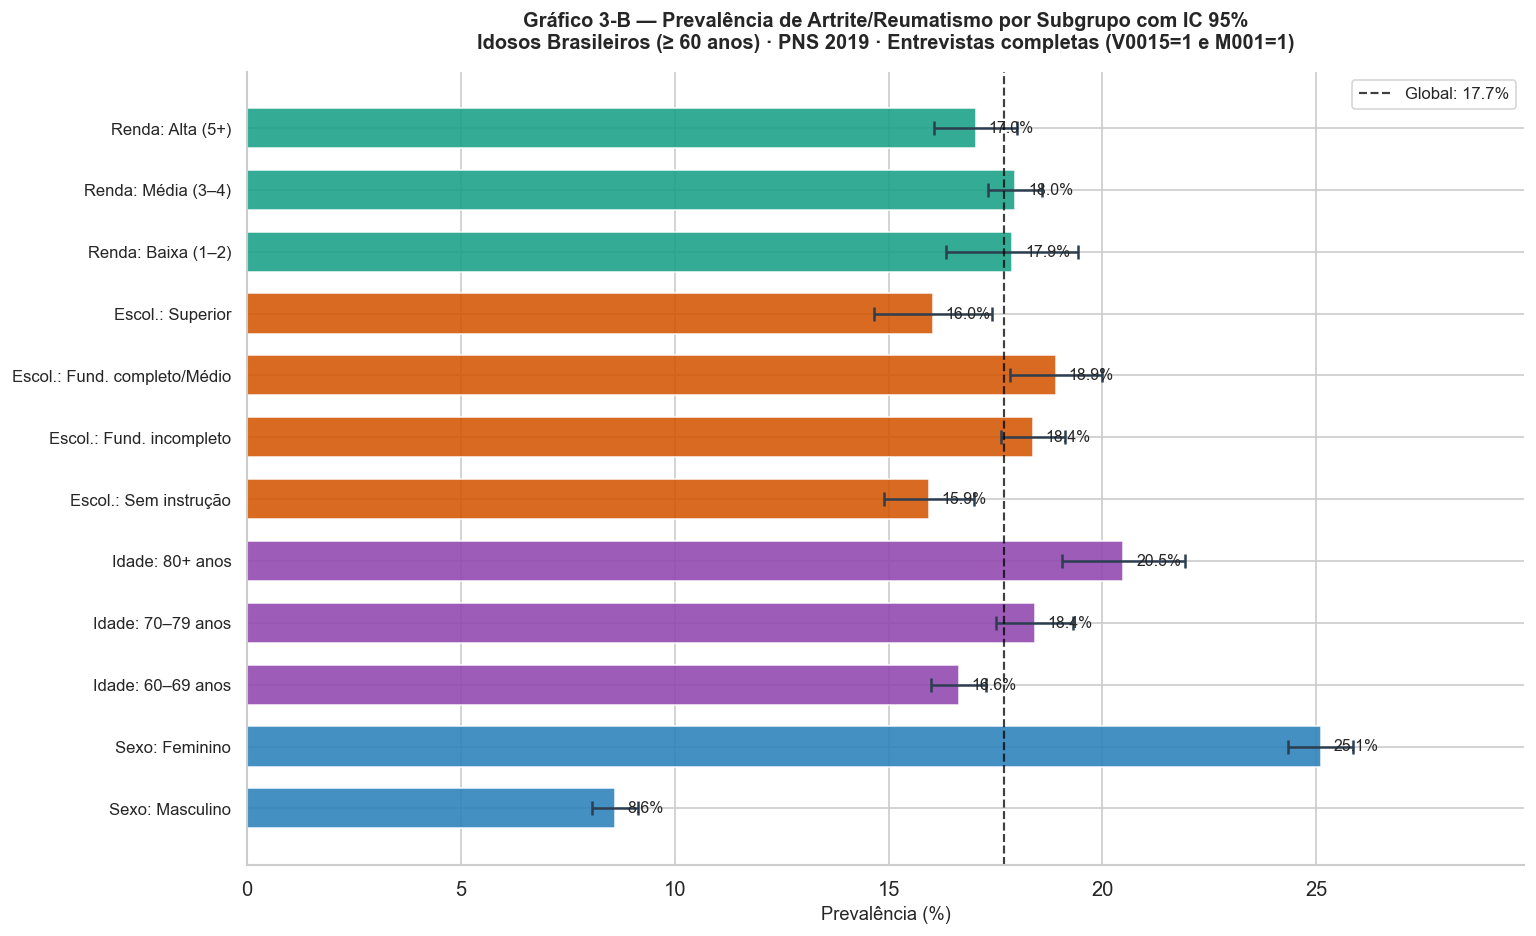

In [4]:
# ── Gráfico 3-B: barras horizontais com IC 95% ────────────────────────────
# BUG 6 CORRIGIDO: antes mostrava 0,0% por causa do bug 1 no Q079
df_plot = tab3b[tab3b['Subgrupo'] != 'Global (Idosos ≥60)'].copy().reset_index(drop=True)  # Remove global, reseta índice

def cor_sub(s):  # Função para atribuir cor a cada subgrupo baseado em sua categoria
    if 'Sexo'   in s: return '#2980B9'  # Azul para categorias de sexo
    if 'Idade'  in s: return '#8E44AD'  # Roxo para categorias de idade
    if 'Escol.' in s: return '#D35400'  # Laranja para categorias de escolaridade
    if 'Renda'  in s: return '#16A085'  # Verde-azulado para categorias de renda
    return '#7F8C8D'  # Cinza para outros

cores = [cor_sub(s) for s in df_plot['Subgrupo']]  # Lista de cores para cada subgrupo
y_pos = range(len(df_plot))  # Posições Y (0, 1, 2, ...) para cada barra
prev_g = tab3b.loc[tab3b['Subgrupo']=='Global (Idosos ≥60)', 'Prevalência (%)'].values[0]  # Prevalência global (para linha de referência)

fig, ax = plt.subplots(figsize=(13, 8))  # Cria figura e eixo com tamanho 13x8 polegadas
ax.barh(list(y_pos), df_plot['Prevalência (%)'],  # Cria barras horizontais com prevalência em %
        color=cores, height=0.65, alpha=0.87, edgecolor='white')  # Cor personalizada, altura, opacidade e borda

# IC 95% como barras de erro
err_inf = df_plot['Prevalência (%)'] - df_plot['IC95% Inf (%)']  # Diferença para limite inferior
err_sup = df_plot['IC95% Sup (%)']   - df_plot['Prevalência (%)']  # Diferença para limite superior
ax.errorbar(df_plot['Prevalência (%)'], list(y_pos),  # Posição central das barras de erro
            xerr=[err_inf, err_sup], fmt='none',  # Erros em X (horizontal), sem marcadores
            color='#2C3E50', capsize=4, capthick=1.5, linewidth=1.5)  # Cor, tamanho das terminações, espessura

# Linha de referência global
ax.axvline(prev_g, color='black', linestyle='--', linewidth=1.3, alpha=0.75,  # Linha vertical tracejada
           label=f'Global: {prev_g:.1f}%')  # Rótulo mostrando prevalência global

for i, row in df_plot.iterrows():  # Para cada subgrupo
    # ax.text: posiciona o valor numérico de prevalência à direita de cada barra horizontal
    ax.text(
        row['Prevalência (%)'] + 0.3,   # posição X: ligeiramente à direita da barra
        i,                               # posição Y: mesma linha da barra
        f"{row['Prevalência (%)']:.1f}%",  # texto exibido: valor com 1 casa decimal + símbolo %
        va='center', fontsize=9.5        # alinhamento vertical centralizado, tamanho 9.5
    )

ax.set_yticks(list(y_pos))  # Define posições Y dos ticks
ax.set_yticklabels(df_plot['Subgrupo'], fontsize=10)  # Rótulos dos subgrupos no eixo Y
ax.set_xlabel('Prevalência (%)', fontsize=11)  # Rótulo do eixo X
xlim_sup = df_plot['IC95% Sup (%)'].max() + 4  # Limite superior do eixo X (com margem)
ax.set_xlim(0, xlim_sup if xlim_sup > 5 else 30)  # Define limites X (mínimo 30)
ax.set_title(  # Título da figura
    'Gráfico 3-B — Prevalência de Artrite/Reumatismo por Subgrupo com IC 95%\n'  # Primeira linha do título
    'Idosos Brasileiros (≥ 60 anos) · PNS 2019 · Entrevistas completas (V0015=1 e M001=1)',  # Segunda linha
    fontsize=12, fontweight='bold', pad=14)  # Formatação do título
ax.legend(fontsize=10)  # Mostra legenda (linha de referência global)
plt.tight_layout()  # Ajusta automaticamente espaços
salvar_fig('grafico_3B_prevalencia_subgrupos.png')  # Salva figura
plt.show()  # Mostra figura na tela


---
## 3.2 · Comparação das Quatro Bases
**Produtos:** Tabela 3-A (descritiva) · Tabela 3-A (testes) · Gráfico 3-A

> ⚠️ As 4 bases **se sobrepõem** por construção (`Geral` contém todas; `Artrite Pura` está contida em `Artrite c/comor.`),
> então **não** se aplica teste ômnibus entre bases (Kruskal-Wallis/Dunn/χ²). A Tab 3-A é **descritiva**;
> os testes inferenciais ficam restritos a **grupos disjuntos vs Saudáveis** (Mann-Whitney U) e **apenas em
> variáveis quantitativas**. Hipertensão/Diabetes não são testadas (0% por definição em Saudáveis/Artrite
> Pura → viés circular). Filtros `V0015=1` e `M001=1` aplicados em cada base.

In [5]:
BANCOS = {  # Dicionário mapeando nomes descritivos para arquivos de banco de dados
    'Geral'              : 'idosos_geral.db',  # Base com todos os idosos
    'Artrite (c/ comor.)': 'idosos_artrite.db',  # Base com artrite incluindo comorbidades
    'Artrite Pura'       : 'idosos_artrite_puro.db',  # Base com artrite pura (sem comorbidades)
    'Saudáveis'          : 'idosos_saudaveis.db',  # Base com idosos saudáveis
}
# CORREÇÃO BUG 17: SQL expandido para incluir todas as variáveis previstas no guia
SQL_BASES = 'SELECT V0015, M001, C008, P00104, P00404, C006, Q00201, Q03001, P035, P02501 FROM pns_idosos'  # SQL com demográficas e clínicas

dfs_bases = {}  # Dicionário para armazenar os dataframes de cada base
for nome, arq in BANCOS.items():  # Para cada base de dados
    c = PASTA_DB + arq  # Caminho completo do arquivo
    if not os.path.exists(c):  # Se arquivo não existe
        continue  # Pula para próximo
    conn  = sqlite3.connect(c)  # Abre conexão SQLite
    df_t  = pd.read_sql_query(SQL_BASES, conn)  # Executa SQL e carrega dados
    conn.close()  # Fecha conexão
    n_raw = len(df_t)  # Número de registros brutos

    # BUG 9+10 CORRIGIDOS
    df_t, _ = filtrar_v0015(df_t)  # Aplica filtro V0015
    df_t, _ = filtrar_m001(df_t)  # Aplica filtro M001

    df_t['Idade'] = pd.to_numeric(df_t['C008'], errors='coerce')  # Converte idade para número
    df_t['Peso']  = pd.to_numeric(df_t['P00104'].astype(str).str.replace(',','.'), errors='coerce')  # Converte peso
    df_t['Alt']   = pd.to_numeric(df_t['P00404'].astype(str).str.replace(',','.'), errors='coerce')  # Converte altura
    df_t['IMC']   = df_t['Peso'] / ((df_t['Alt']/100)**2)  # Calcula IMC
    df_t['IMC']   = df_t['IMC'].where((df_t['IMC'] >= 10) & (df_t['IMC'] <= 70))  # sanidade [10,70] kg/m² -> NaN
    df_t['Base']  = nome  # Adiciona coluna identificando a base
    # CORREÇÃO BUG 17: variáveis qualitativas para Tab 3-A expandida
    df_t['Feminino']     = df_t['C006'].astype(str).str.strip().isin(['2','Mulher']).astype(int) if 'C006' in df_t.columns else None  # 1=mulher, 0=homem
    df_t['Hipertensao']  = (df_t['Q00201'].astype(str).str.strip().str.lower().map({'1':1,'1.0':1,'sim':1,'s':1,'2':0,'não':0,'nao':0,'n':0}) if 'Q00201' in df_t.columns else None)  # robusto a 'Sim'/'Não' (texto) ou 1/2
    df_t['Diabetes']     = (df_t['Q03001'].astype(str).str.strip().str.lower().map({'1':1,'1.0':1,'sim':1,'s':1,'2':0,'não':0,'nao':0,'n':0}) if 'Q03001' in df_t.columns else None)  # robusto a 'Sim'/'Não' (texto) ou 1/2
    df_t['Exercicio']    = pd.to_numeric(df_t['P035'], errors='coerce') if 'P035' in df_t.columns else None  # dias/semana
    df_t['Ultraproc']    = pd.to_numeric(df_t['P02501'], errors='coerce') if 'P02501' in df_t.columns else None  # dias/semana
    dfs_bases[nome] = df_t  # Armazena dataframe
    print(f'  📦 {nome:22s}: {n_raw:,} bruto → {len(df_t):,} válidos')  # Mostra progresso

df_all = pd.concat(dfs_bases.values(), ignore_index=True)  # Combina todas as bases em uma

tab3a_linhas = []  # DESCRITIVA: uma linha por (variável × base)

# == Tab 3-A: DESCRITIVA (4 bases) + contrastes inferenciais VALIDOS ==================
# As 4 bases se SOBREPOEM por construcao: Geral contem todas e Artrite Pura e subconjunto
# de Artrite c/comor. Logo testes omnibus entre bases (Kruskal-Wallis/Dunn/chi2) violam
# independencia. Alem disso, Hipertensao/Diabetes sao 0% por DEFINICAO em Saudaveis/Artrite
# Pura (vies circular: as comorbidades definem os grupos). Portanto:
#   - A Tab 3-A e apresentada como DESCRITIVA das 4 coortes.
#   - Testes inferenciais SO nas variaveis QUANTITATIVAS e SO entre grupos DISJUNTOS
#     (Artrite Pura vs Saudaveis e Artrite c/comor vs Saudaveis) -- Mann-Whitney U.
#   - Geral entra apenas como referencia descritiva (sem teste).
VARS_QUANT_3A = ['Idade', 'IMC', 'Exercicio', 'Ultraproc']
VARS_BIN_3A   = {'Feminino': '% Feminino', 'Hipertensao': '% Hipertensão', 'Diabetes': '% Diabetes'}

for var in VARS_QUANT_3A:
    for b in BANCOS:
        if b not in dfs_bases: continue
        s = df_all[df_all['Base'] == b][var].dropna()
        if len(s) == 0: continue
        tab3a_linhas.append({'Variável': var, 'Tipo': 'Quant.', 'Base': b, 'n': len(s),
            'Mediana (IQR)': f'{s.median():.1f} ({s.quantile(.25):.1f}–{s.quantile(.75):.1f})',
            'Média±DP': f'{s.mean():.1f}±{s.std():.1f}'})
for var, rot in VARS_BIN_3A.items():
    for b in BANCOS:
        if b not in dfs_bases: continue
        s = df_all[df_all['Base'] == b][var].dropna()
        if len(s) == 0: continue
        pct = 100 * int(s.sum()) / len(s)
        tab3a_linhas.append({'Variável': rot, 'Tipo': 'Binária', 'Base': b, 'n': len(s),
            'Mediana (IQR)': f'{pct:.1f}%', 'Média±DP': f'{pct:.1f}%'})

tab3a = pd.DataFrame(tab3a_linhas)
print('\n' + '=' * 88)
print('  TABELA 3-A — Caracterização DESCRITIVA das 4 bases (coortes sobrepostas)')
print('  Sem teste ômnibus entre bases: Geral contém todas e Artrite Pura está em Artrite c/comor.')
print('=' * 88)
if not tab3a.empty: print(tab3a.to_string(index=False))
salvar_tab(tab3a, 'tabela_3A_descritiva_quatro_bases.csv')

# == Contrastes inferenciais VALIDOS (grupos disjuntos) -- so quantitativas ==========
CONTRASTES_3A = [g for g in ['Artrite Pura', 'Artrite (c/ comor.)'] if g in dfs_bases]
linhas_teste = []
if 'Saudáveis' in dfs_bases:
    for var in VARS_QUANT_3A:
        s2 = df_all[df_all['Base'] == 'Saudáveis'][var].dropna()
        for g1 in CONTRASTES_3A:
            s1 = df_all[df_all['Base'] == g1][var].dropna()
            if len(s1) < 5 or len(s2) < 5: continue
            U, p = stats.mannwhitneyu(s1, s2, alternative='two-sided')
            linhas_teste.append({'Variável': var, 'Grupo': g1, 'n grupo': len(s1),
                'Med grupo': round(s1.median(), 1), 'n Saudáveis': len(s2),
                'Med Saudáveis': round(s2.median(), 1), 'Teste': 'Mann-Whitney U',
                'U': f'{U:.0f}', 'p-valor': f'{p:.4e}', 'Sig.': sig(p)})
tab3a_testes = pd.DataFrame(linhas_teste)
print('\n' + '=' * 88)
print('  TABELA 3-A (testes) — Contrastes VÁLIDOS vs Saudáveis (grupos disjuntos) · Mann-Whitney U')
print('  Hipertensão/Diabetes NÃO testadas: 0% por construção em Saudáveis/Artrite Pura (viés circular).')
print('=' * 88)
if not tab3a_testes.empty: print(tab3a_testes.to_string(index=False))
salvar_tab(tab3a_testes, 'tabela_3A_contrastes_validos.csv')


  📦 Geral                 : 43,554 bruto → 22,728 válidos
  📦 Artrite (c/ comor.)   : 4,025 bruto → 4,025 válidos
  📦 Artrite Pura          : 494 bruto → 494 válidos


  📦 Saudáveis             : 4,332 bruto → 4,332 válidos



  TABELA 3-A — Caracterização DESCRITIVA das 4 bases (coortes sobrepostas)
  Sem teste ômnibus entre bases: Geral contém todas e Artrite Pura está em Artrite c/comor.
     Variável    Tipo                Base     n    Mediana (IQR) Média±DP
        Idade  Quant.               Geral 22728 68.0 (64.0–75.0) 70.0±7.9
        Idade  Quant. Artrite (c/ comor.)  4025 69.0 (64.0–76.0) 70.7±8.0
        Idade  Quant.        Artrite Pura   494 67.0 (63.0–75.0) 69.7±8.4
        Idade  Quant.           Saudáveis  4332 67.0 (63.0–73.0) 68.7±7.6
          IMC  Quant.               Geral 22726 25.9 (23.3–29.0) 26.4±4.6
          IMC  Quant. Artrite (c/ comor.)  4025 26.8 (23.9–30.1) 27.3±5.1
          IMC  Quant.        Artrite Pura   494 25.3 (22.8–28.4) 25.7±4.3
          IMC  Quant.           Saudáveis  4330 24.8 (22.5–27.5) 25.2±4.0
    Exercicio  Quant.               Geral  6472    3.0 (2.0–5.0)  3.9±1.9
    Exercicio  Quant. Artrite (c/ comor.)  1120    3.0 (2.0–5.0)  3.7±1.8
    Exercicio  Qua

  ✅ Figura → ../data/results/eda/figuras/grafico_3A_boxplots_quatro_bases.png


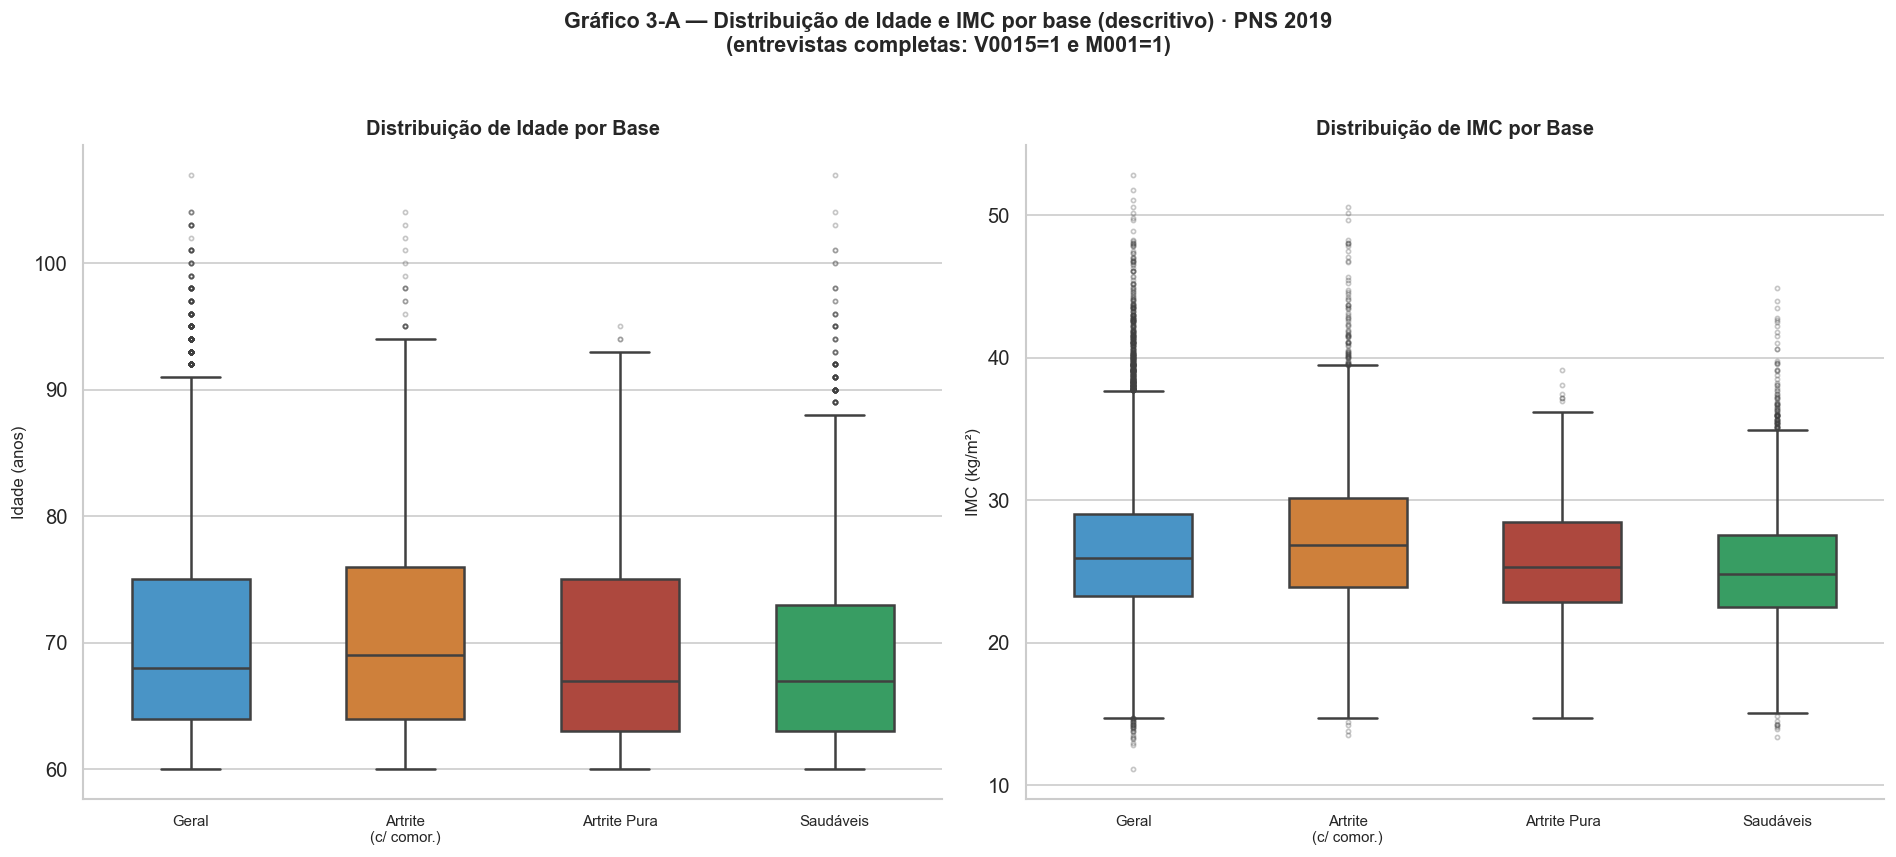

In [6]:
# BUG 12 CORRIGIDO: set_xticks() antes de set_xticklabels() evita FixedLocator warning
if df_all.empty:  # Se dataframe de todas as bases está vazio
    print('⚠️  df_all vazio — gráfico 3-A não gerado.')  # Aviso
else:  # Se há dados
    nomes_bases = [b for b in BANCOS if b in dfs_bases]  # Lista de nomes das bases carregadas
    PALETA_BASES = dict(zip(nomes_bases, ['#3498DB','#E67E22','#C0392B','#27AE60'][:len(nomes_bases)]))  # Mapa de cores para bases

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))  # Cria figura com 2 subplots (1 linha, 2 colunas)
    for ax, var in zip(axes, ['Idade','IMC']):  # Para cada variável (Idade e IMC)
        dados = df_all[['Base', var]].dropna()  # Extrai dados válidos (sem NaN)
        order = nomes_bases  # Ordem das bases no gráfico
        sns.boxplot(data=dados, x='Base', y=var, ax=ax,  # Cria boxplot
                    order=order, palette=PALETA_BASES,  # Ordem e cores
                    width=0.55, linewidth=1.5,  # Largura e espessura de linha
                    flierprops=dict(marker='o', markersize=2.5, alpha=0.3))  # Estilo de outliers
        ax.set_title(f'Distribuição de {var} por Base', fontsize=12, fontweight='bold')  # Título do subplot
        ax.set_xlabel('')  # Sem rótulo X
        # Rótulo do eixo Y: mostra a unidade correta — "anos" para Idade, "kg/m²" para IMC
        unidade = 'anos' if var == 'Idade' else 'kg/m²'  # Define unidade conforme a variável
        ax.set_ylabel(f'{var} ({unidade})', fontsize=10)  # Aplica rótulo com unidade
        # BUG 12: set_xticks obrigatório antes de set_xticklabels
        ax.set_xticks(range(len(order)))  # Define posições dos ticks em X
        ax.set_xticklabels([b.replace(' (',  '\n(') for b in order], fontsize=9)  # Rótulos quebrados em 2 linhas

    fig.suptitle(  # Título geral da figura
        'Gráfico 3-A — Distribuição de Idade e IMC por base (descritivo) · PNS 2019\n'  # Primeira linha
        '(entrevistas completas: V0015=1 e M001=1)',  # Segunda linha
        fontsize=13, fontweight='bold', y=1.02)  # Formatação
    plt.tight_layout()  # Ajusta espaçamento automaticamente
    salvar_fig('grafico_3A_boxplots_quatro_bases.png')  # Salva figura
    plt.show()  # Mostra figura


---
## 2.1 · Univariada — Variáveis Quantitativas
**Produtos:** Tabela 2-A · Gráfico 2-A

In [7]:
VARS_QUANT = {  # Dicionário de variáveis quantitativas: código → descrição
    'Idade'  : 'Idade (anos)',  # Idade do entrevistado
    'IMC'    : 'IMC (kg/m²)',  # Índice de Massa Corporal
    'Renda'  : 'Renda (faixa)',  # VDF004 - faixa de rendimento domiciliar per capita (1-7)
    'P035'   : 'Exercício (dias/sem.)',  # Dias de exercício por semana
    'P04501' : 'TV (horas/dia)',  # Horas de TV por dia
    'P018'   : 'Frutas (dias/sem.)',  # Dias de consumo de frutas por semana
    'P00901' : 'Verduras (dias/sem.)',  # Dias de consumo de verduras por semana
    'P015'   : 'Peixe (dias/sem.)',  # Dias de consumo de peixe por semana
    'P01101' : 'Carne vermelha (dias/sem.)',  # Dias de consumo de carne vermelha por semana
    'P02501' : 'Doces/ultraproc. (dias/sem.)',  # Dias de consumo de doces/ultraprocessados por semana
    'P02002' : 'Refrigerante (dias/sem.)',  # Dias de consumo de refrigerante por semana
    # MELHORIA 24: Variáveis CAPTO previstas no guia — padrão alimentar complementar
    'P02001' : 'Suco em pó/caixinha (dias/sem.)',  # P02001 - suco de caixinha/lata ou refresco em pó (pró-inflamatório)
    'P023'   : 'Leite (dias/sem.)',  # P023 - dias de consumo de leite por semana
    'P01601' : 'Suco de fruta natural (dias/sem.)',  # P01601 - suco de fruta natural (anti-inflamatório)
    'P02602' : 'Substituir almoço por lanche (dias/sem.)',  # P02602 - substituir o almoço por lanche rápido (ultraprocessado)
    'P006'   : 'Feijão (dias/sem.)',  # P006 - dias/semana que come feijão
    'P013'   : 'Frango (dias/sem.)',  # P013 - dias/semana que come frango/galinha
}

# MELHORIA 21: Tab 2-A reformatada para formato WIDE (padrão JHI — \"Tabela 1\" de artigo científico)
# Cada variável ocupa uma linha; colunas Artrite e Saudável paralelas com p-valor (Mann-Whitney U).
# Formato: Variável | Artrite Med(IQR) | Saudável Med(IQR) | p-valor | Sig. | Normal?
linhas2a_raw = {}  # Dicionário para armazenar estatísticas descritivas
for col, rotulo in VARS_QUANT.items():  # Para cada variável quantitativa
    linhas2a_raw[rotulo] = {}  # Cria entrada para esta variável
    for grupo in ['Com Artrite','Saudável']:  # Para cada grupo de comparação
        s = df_biv[df_biv['Classe']==grupo][col].dropna()  # Extrai dados válidos (sem NaN)
        n = len(s)  # Número de observações válidas
        if n < 3: continue  # Pula se menos de 3 observações (insuficiente para testes)
        amostra = s.sample(min(n, 5000), random_state=RANDOM_STATE)  # Amostra máximo 5000 para Shapiro (teste é lento com n grande)
        _, p_norm = stats.shapiro(amostra)  # Teste Shapiro-Wilk para normalidade
        q1, q3 = s.quantile([.25,.75])  # Quartis Q1 e Q3
        linhas2a_raw[rotulo][grupo] = {  # Armazena estatísticas
            'n': n, 'media': s.mean(), 'dp': s.std(),  # n, média e desvio padrão
            'mediana': s.median(), 'q1': q1, 'q3': q3,  # Mediana e quartis
            'min': s.min(), 'max': s.max(),  # Mínimo e máximo
            'normal': p_norm > ALPHA, 'p_norm': p_norm  # Flag normalidade e p-valor do teste
        }

tab2a_rows = []  # Lista para armazenar linhas da tabela
for col, rotulo in VARS_QUANT.items():  # Para cada variável quantitativa
    d = linhas2a_raw.get(rotulo, {})  # Busca estatísticas desta variável
    if 'Com Artrite' not in d or 'Saudável' not in d: continue  # Pula se faltam dados de algum grupo
    da, ds = d['Com Artrite'], d['Saudável']  # Desempacota dados dos grupos
    # Teste bivariado (Mann-Whitney U — quase sempre não-normal com Shapiro em n grande)
    s1 = df_biv[df_biv['Classe']=='Com Artrite'][col].dropna()  # Dados do grupo Artrite
    s2 = df_biv[df_biv['Classe']=='Saudável'][col].dropna()  # Dados do grupo Saudável
    if len(s1) >= 5 and len(s2) >= 5:  # Se ambos grupos têm ≥5 observações
        _, p_biv = stats.mannwhitneyu(s1, s2, alternative='two-sided')  # Teste Mann-Whitney U
    else:  # Se não há dados suficientes
        p_biv = float('nan')  # Define p-valor como NaN (não calculável)
    # Monta uma linha da Tabela 2-A com estatísticas de ambos os grupos lado a lado (formato wide)
    tab2a_rows.append({
        'Variável'          : rotulo,       # Nome legível da variável (ex: "Idade (anos)")
        'n Artrite'         : da['n'],      # Número de observações válidas no grupo Artrite
        # Mediana e IQR (Q1–Q3) do grupo Artrite — formato: "mediana (Q1–Q3)"
        'Artrite Md (IQR)'  : f"{da['mediana']:.1f} ({da['q1']:.1f}–{da['q3']:.1f})",
        # Média ± desvio padrão do grupo Artrite — formato: "média±DP"
        'Artrite Méd±DP'    : f"{da['media']:.1f}±{da['dp']:.1f}",
        'n Saudável'        : ds['n'],      # Número de observações válidas no grupo Saudável
        # Mediana e IQR (Q1–Q3) do grupo Saudável — formato: "mediana (Q1–Q3)"
        'Saudável Md (IQR)' : f"{ds['mediana']:.1f} ({ds['q1']:.1f}–{ds['q3']:.1f})",
        # Média ± desvio padrão do grupo Saudável — formato: "média±DP"
        'Saudável Méd±DP'   : f"{ds['media']:.1f}±{ds['dp']:.1f}",
        'Teste'             : 'Mann-Whitney U',  # Teste usado (não-paramétrico, adequado para dados assimétricos)
        # p-valor em notação científica; '—' se não foi possível calcular (NaN)
        'p-valor'           : f'{p_biv:.4e}' if not (p_biv != p_biv) else '—',
        # Classificação da significância: ***, **, *, ns
        'Sig.'              : sig(p_biv) if not (p_biv != p_biv) else '—',
        # 'Sim' se ambos os grupos passaram no teste de normalidade Shapiro-Wilk
        'Normal (Shapiro)?' : 'Sim' if (da['normal'] and ds['normal']) else 'Não',
    })

tab2a = pd.DataFrame(tab2a_rows)  # Cria dataframe da tabela 2-A
print('='*130)  # Linha decorativa
print('  TABELA 2-A — Características Basais: Variáveis Quantitativas [formato wide — padrão JHI]')  # Título
print('  [MELHORIA 21: formato wide | MELHORIA 24: P02001 Suco em pó, P023 Leite, P01601 Suco natural, P02602 Subst. almoço, P006 Feijão, P013 Frango]')  # Melhorias
print('='*130)  # Linha decorativa
print(tab2a.to_string(index=False))  # Mostra tabela
salvar_tab(tab2a, 'tabela_2A_univariada_quantitativas.csv')  # Salva tabela


  TABELA 2-A — Características Basais: Variáveis Quantitativas [formato wide — padrão JHI]
  [MELHORIA 21: formato wide | MELHORIA 24: P02001 Suco em pó, P023 Leite, P01601 Suco natural, P02602 Subst. almoço, P006 Feijão, P013 Frango]
                                Variável  n Artrite Artrite Md (IQR) Artrite Méd±DP  n Saudável Saudável Md (IQR) Saudável Méd±DP          Teste    p-valor Sig. Normal (Shapiro)?
                            Idade (anos)        494 67.0 (63.0–75.0)       69.7±8.4        4332  67.0 (63.0–73.0)        68.7±7.6 Mann-Whitney U 5.7926e-02   ns               Não
                             IMC (kg/m²)        494 25.3 (22.8–28.4)       25.7±4.3        4330  24.8 (22.5–27.5)        25.2±4.0 Mann-Whitney U 6.1311e-03   **               Não
                           Renda (faixa)        494    4.0 (3.0–5.0)        3.9±1.5        4331     4.0 (3.0–5.0)         3.9±1.4 Mann-Whitney U 9.7534e-01   ns               Não
                   Exercício (dias/sem.)        1

  ✅ Figura → ../data/results/eda/figuras/grafico_2A_boxplots_quantitativas.png


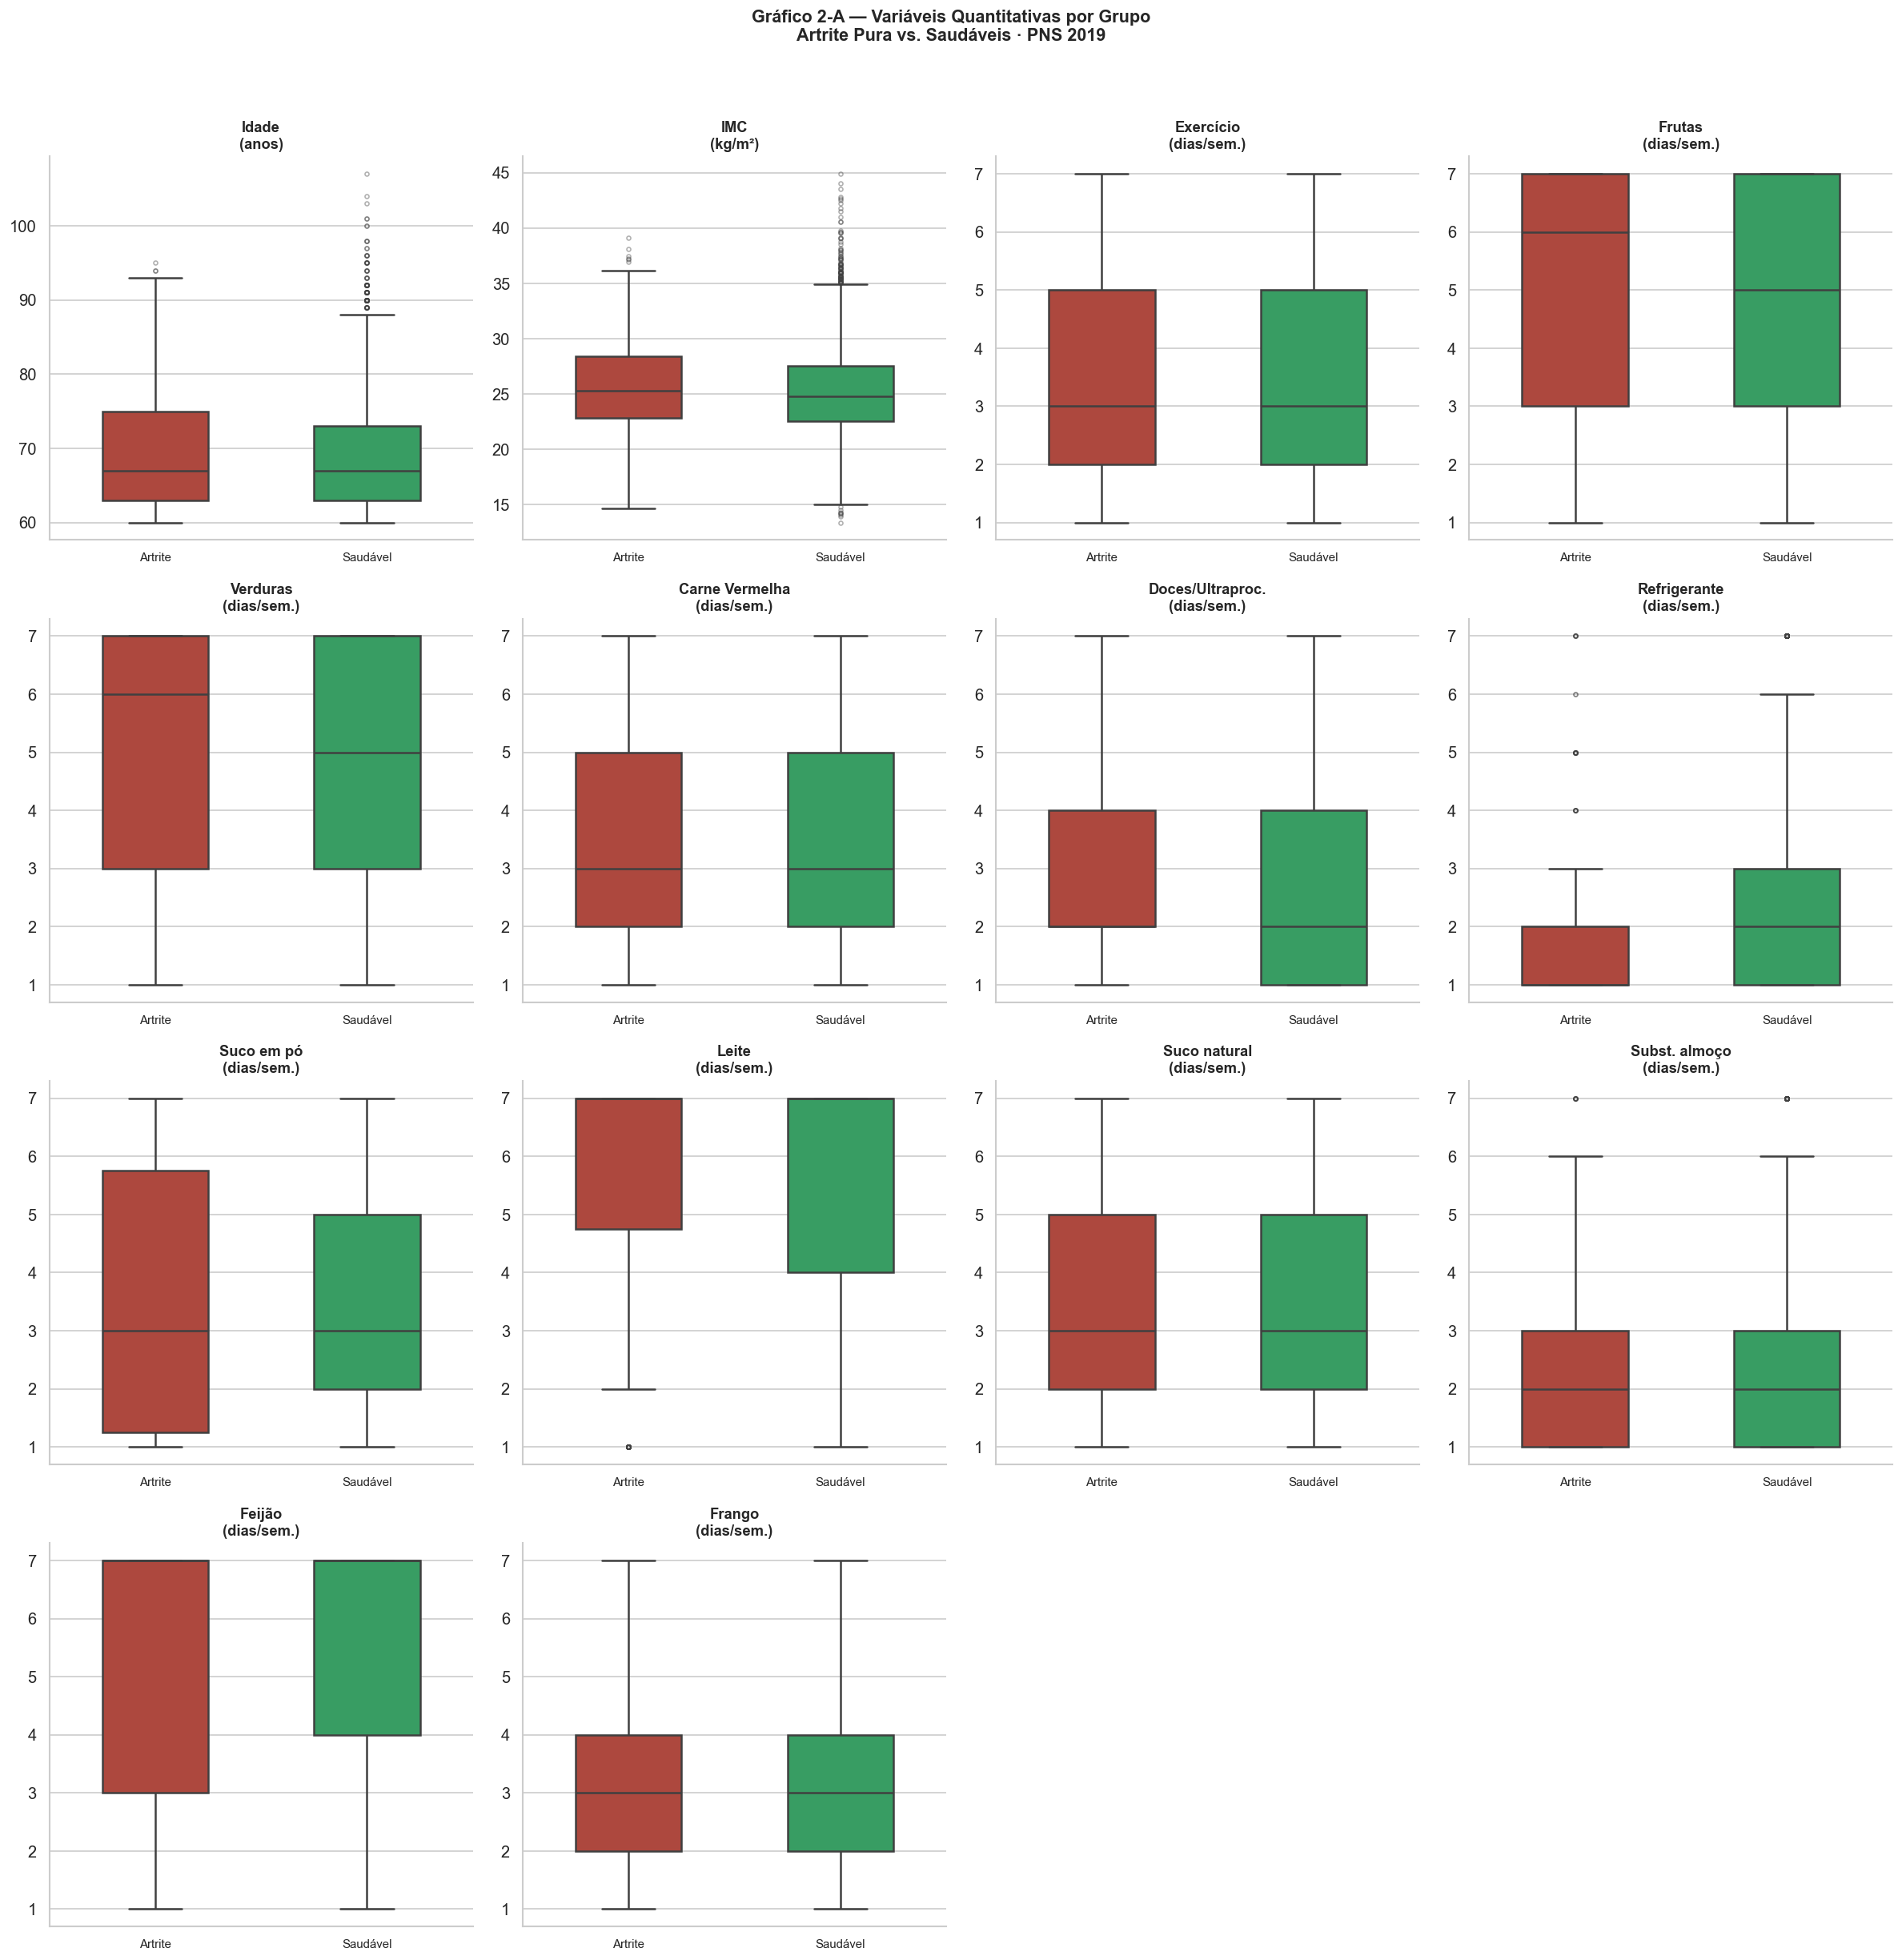

In [8]:
# BUG 13 CORRIGIDO: order= garante só 2 ticks → set_xticklabels com 2 labels
if df_biv.empty:  # Se dataframe bivariado está vazio
    print('⚠️  df_biv vazio — gráfico 2-A não gerado.')  # Aviso
else:  # Se há dados
    # MELHORIA 24: Vars CAPTO adicionadas ao Gráfico 2-A
    VARS_BOXPLOT = {  # Variáveis para exibir em boxplots: código → rótulo
        'Idade'  : 'Idade\n(anos)',  # Idade com quebra de linha
        'IMC'    : 'IMC\n(kg/m²)',  # IMC com quebra de linha
        'P035'   : 'Exercício\n(dias/sem.)',  # Exercício com quebra de linha
        'P018'   : 'Frutas\n(dias/sem.)',  # Frutas com quebra de linha
        'P00901' : 'Verduras\n(dias/sem.)',  # Verduras com quebra de linha
        'P01101' : 'Carne Vermelha\n(dias/sem.)',  # Carne vermelha com quebra de linha
        'P02501' : 'Doces/Ultraproc.\n(dias/sem.)',  # Doces com quebra de linha
        'P02002' : 'Refrigerante\n(dias/sem.)',  # Refrigerante com quebra de linha
        'P02001' : 'Suco em pó\n(dias/sem.)',  # Suco em pó com quebra de linha
        'P023'   : 'Leite\n(dias/sem.)',  # Leite com quebra de linha
        'P01601' : 'Suco natural\n(dias/sem.)',  # Suco natural com quebra de linha
        'P02602' : 'Subst. almoço\n(dias/sem.)',  # Subst. almoço com quebra de linha
        'P006' : 'Feijão\n(dias/sem.)',  # Feijão com quebra de linha
        'P013' : 'Frango\n(dias/sem.)',  # Frango com quebra de linha
    }
    ORDEM_CLASSES = ['Com Artrite', 'Saudável']  # Ordem de apresentação dos grupos

    n_vars = len(VARS_BOXPLOT)  # Número de variáveis a plotar
    n_cols_bp = 4   # 4 painéis por linha
    n_rows_bp = (n_vars + n_cols_bp - 1) // n_cols_bp  # Número de linhas necessário (arredonda para cima)
    fig, axes = plt.subplots(n_rows_bp, n_cols_bp,  # Cria matriz de subplots
                             figsize=(5*n_cols_bp, 5*n_rows_bp))  # Tamanho proporcional ao número de subplots
    axes = axes.flatten()  # Transforma matriz em vetor 1D
    for ax, (col, label) in zip(axes, VARS_BOXPLOT.items()):  # Para cada variável
        dados = df_biv[['Classe', col]].dropna()  # Extrai dados válidos
        if dados.empty:  # Se não há dados
            ax.set_title(label + '\n(sem dados)', fontsize=10)  # Mostra "sem dados"
            continue  # Pula para próximo
        sns.boxplot(data=dados, x='Classe', y=col, ax=ax,  # Cria boxplot
                    order=ORDEM_CLASSES,  # Ordem dos grupos
                    palette={'Com Artrite': COR_ARTRITE, 'Saudável': COR_SAUDAVEL},  # Cores padrão
                    width=0.5, linewidth=1.5,  # Dimensões
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))  # Estilo de outliers
        ax.set_title(label, fontsize=11, fontweight='bold')  # Título do subplot
        ax.set_xlabel('')  # Sem rótulo X
        ax.set_ylabel('')  # Sem rótulo Y
        # BUG 13: set_xticks antes de set_xticklabels
        ax.set_xticks(range(len(ORDEM_CLASSES)))  # Define posições dos ticks
        ax.set_xticklabels(['Artrite', 'Saudável'], fontsize=9)  # Rótulos simplificados

    fig.suptitle(  # Título geral da figura
        'Gráfico 2-A — Variáveis Quantitativas por Grupo\n'  # Primeira linha
        'Artrite Pura vs. Saudáveis · PNS 2019',  # Segunda linha
        fontsize=13, fontweight='bold', y=1.02)  # Formatação
    # Ocultar painéis vazios (quando n_vars não é múltiplo de n_cols_bp)
    for ax_extra in axes[n_vars:]:  # Para cada subplot vazio
        ax_extra.set_visible(False)  # Oculta o subplot
    plt.tight_layout()  # Ajusta espaçamento automaticamente
    salvar_fig('grafico_2A_boxplots_quantitativas.png')  # Salva figura
    plt.show()  # Mostra figura


---
## 2.2 · Univariada — Variáveis Qualitativas
**Produtos:** Tabela 2-B · Gráfico 2-B

> **Bug 4 corrigido:** eixo Y agora em **0–100%** em vez de 0–1.  
> **Bug 5 corrigido:** `sum(axis=1)` em vez de `sum(1)` (Pandas ≥4).

In [9]:
# Mapeamentos código → rótulo legível (Dicionário PNS 2019)
MAP_SEXO  = {'1':'Homem',    '2':'Mulher'}  # Mapa de códigos de sexo para texto
MAP_SN    = {'1':'Sim',      '2':'Não'}  # Mapa de códigos Sim/Não
MAP_N001  = {'1':'Muito boa','2':'Boa','3':'Regular','4':'Ruim','5':'Muito ruim'}  # Mapa de autoavaliação de saúde

# CORREÇÃO BUG 14: Q092 removida — variável constante nesta amostra (critério de inclusão:
# artrite pura exclui comorbidades de saúde mental, logo 100% Não). Inútil como preditor.
# CORREÇÃO BUG 18: N001 (autoavaliação de saúde) adicionada — variável prevista no guia CAPTO.
VARS_QUAL = {  # Dicionário de variáveis qualitativas: código → (rótulo, mapa de códigos)
    'C006'   : ('Sexo',                MAP_SEXO),  # Sexo do entrevistado
    'P034'   : ('Praticou Exercício',  MAP_SN),  # Praticou exercício na última semana
    'I00102' : ('Plano de saúde médico', MAP_SN),  # I00102 - tem plano de saúde médico
    'N001'   : ('Autoavaliação Saúde', MAP_N001),  # Como avalia sua própria saúde
    'VDD004A': ('Escolaridade',        None),  # Escolaridade (usará valores originais)
    'P00620' : ('Embutidos (dia anterior)', MAP_SN),  # P00620 - comeu embutidos no dia anterior (Sim/Não)
}

# MELHORIA 21 + BUG 15: Tab 2-B reformatada para formato WIDE (padrão JHI — \"Tabela 1\").
# Cada variável/categoria ocupa uma linha com colunas Artrite e Saudável paralelas + p-valor.
# Formato: Variável | Categoria | n Artrite | % Artrite | n Saudável | % Saudável | Teste | p-valor | Sig.
linhas2b = []  # Lista para armazenar linhas da tabela
for col, (rotulo, mapa) in VARS_QUAL.items():  # Para cada variável qualitativa
    # Calcular p-valor global para a variável (χ² ou Fisher)
    serie_all = df_biv[col].dropna().astype(str).str.strip()  # Remove NaN antes de converter para string (evita categoria 'nan')
    if mapa: serie_all = serie_all.map(mapa).fillna(serie_all)  # Aplica mapeamento código→texto (se não mapeado, mantém original)
    tab_ct = pd.crosstab(serie_all, df_biv['Classe'])  # Tabela de contingência: categorias vs grupos
    if tab_ct.empty or tab_ct.shape[0] < 2:  # Se tabela vazia ou só 1 categoria
        p_var, teste_var = float('nan'), '—'  # Não pode fazer teste
    elif tab_ct.values.min() < 5 and tab_ct.shape == (2,2):  # Se tabela 2x2 com células <5
        _, p_var = stats.fisher_exact(tab_ct.values)  # Usa teste exato de Fisher
        teste_var = 'Fisher'  # Identifica teste
    else:  # Se tabela tem células ≥5 ou é maior que 2x2
        chi2_v, p_var, _, _ = stats.chi2_contingency(tab_ct)  # Usa teste χ²
        teste_var = 'χ²'  # Identifica teste

    # Contar n e % por categoria em cada grupo
    serie_art = df_biv[df_biv['Classe']=='Com Artrite'][col].dropna().astype(str).str.strip()  # Dados do grupo Artrite (sem NaN)
    serie_sau = df_biv[df_biv['Classe']=='Saudável'][col].dropna().astype(str).str.strip()  # Dados do grupo Saudável (sem NaN)
    if mapa:  # Se há mapeamento definido
        serie_art = serie_art.map(mapa).fillna(serie_art)  # Aplica mapeamento Artrite
        serie_sau = serie_sau.map(mapa).fillna(serie_sau)  # Aplica mapeamento Saudável
    n_art_tot = len(serie_art); n_sau_tot = len(serie_sau)  # Total de observações por grupo

    # Categorias ordenadas pela frequência total
    cats = serie_all.value_counts(dropna=True).index.tolist()  # Categorias ordenadas por frequência
    first = True  # Flag para colocar p-valor só na primeira categoria
    for cat in cats:  # Para cada categoria
        n_a = int((serie_art == cat).sum())  # Contar em Artrite
        n_s = int((serie_sau == cat).sum())  # Contar em Saudável
        pct_a = round(100 * n_a / n_art_tot, 1) if n_art_tot > 0 else 0  # % em Artrite
        pct_s = round(100 * n_s / n_sau_tot, 1) if n_sau_tot > 0 else 0  # % em Saudável
        linhas2b.append({  # Adiciona linha
            'Variável'   : rotulo if first else '',  # Nome da variável (só na primeira linha)
            'Categoria'  : cat,  # Categoria
            'n Artrite'  : n_a,  # n em Artrite
            '% Artrite'  : pct_a,  # % em Artrite
            'n Saudável' : n_s,  # n em Saudável
            '% Saudável' : pct_s,  # % em Saudável
            'Teste'      : teste_var if first else '',  # Nome do teste (só na primeira linha)
            'p-valor'    : f'{p_var:.4e}' if (first and p_var == p_var) else '',  # p-valor (só na primeira linha, se não NaN)
            'Sig.'       : sig(p_var) if (first and p_var == p_var) else '',  # Significância (só na primeira linha)
        })
        first = False  # Depois da primeira, não mais mostra teste/p-valor

tab2b = pd.DataFrame(linhas2b)  # Cria dataframe da tabela
print('='*110)  # Linha decorativa
print('  TABELA 2-B — Características Basais: Variáveis Qualitativas [formato wide — padrão JHI]')  # Título
print('  [MELHORIA 21: wide | BUG 14: Q092 removida | BUG 15: p-valor | BUG 18: N001]')  # Melhorias
print('='*110)  # Linha decorativa
print(tab2b.to_string(index=False))  # Mostra tabela
salvar_tab(tab2b, 'tabela_2B_univariada_qualitativas.csv')  # Salva tabela


  TABELA 2-B — Características Basais: Variáveis Qualitativas [formato wide — padrão JHI]
  [MELHORIA 21: wide | BUG 14: Q092 removida | BUG 15: p-valor | BUG 18: N001]
                Variável                             Categoria  n Artrite  % Artrite  n Saudável  % Saudável Teste    p-valor Sig.
                    Sexo                                 Homem        173       35.0        2501        57.7    χ² 1.0247e-21  ***
                                                        Mulher        321       65.0        1831        42.3                      
      Praticou Exercício                                   Não        360       72.9        3084        71.2    χ² 4.6440e-01   ns
                                                           Sim        134       27.1        1248        28.8                      
   Plano de saúde médico                                   Não        363       73.5        3380        78.0    χ² 2.5366e-02    *
                                             

  ✅ Figura → ../data/results/eda/figuras/grafico_2B_barras_qualitativas.png


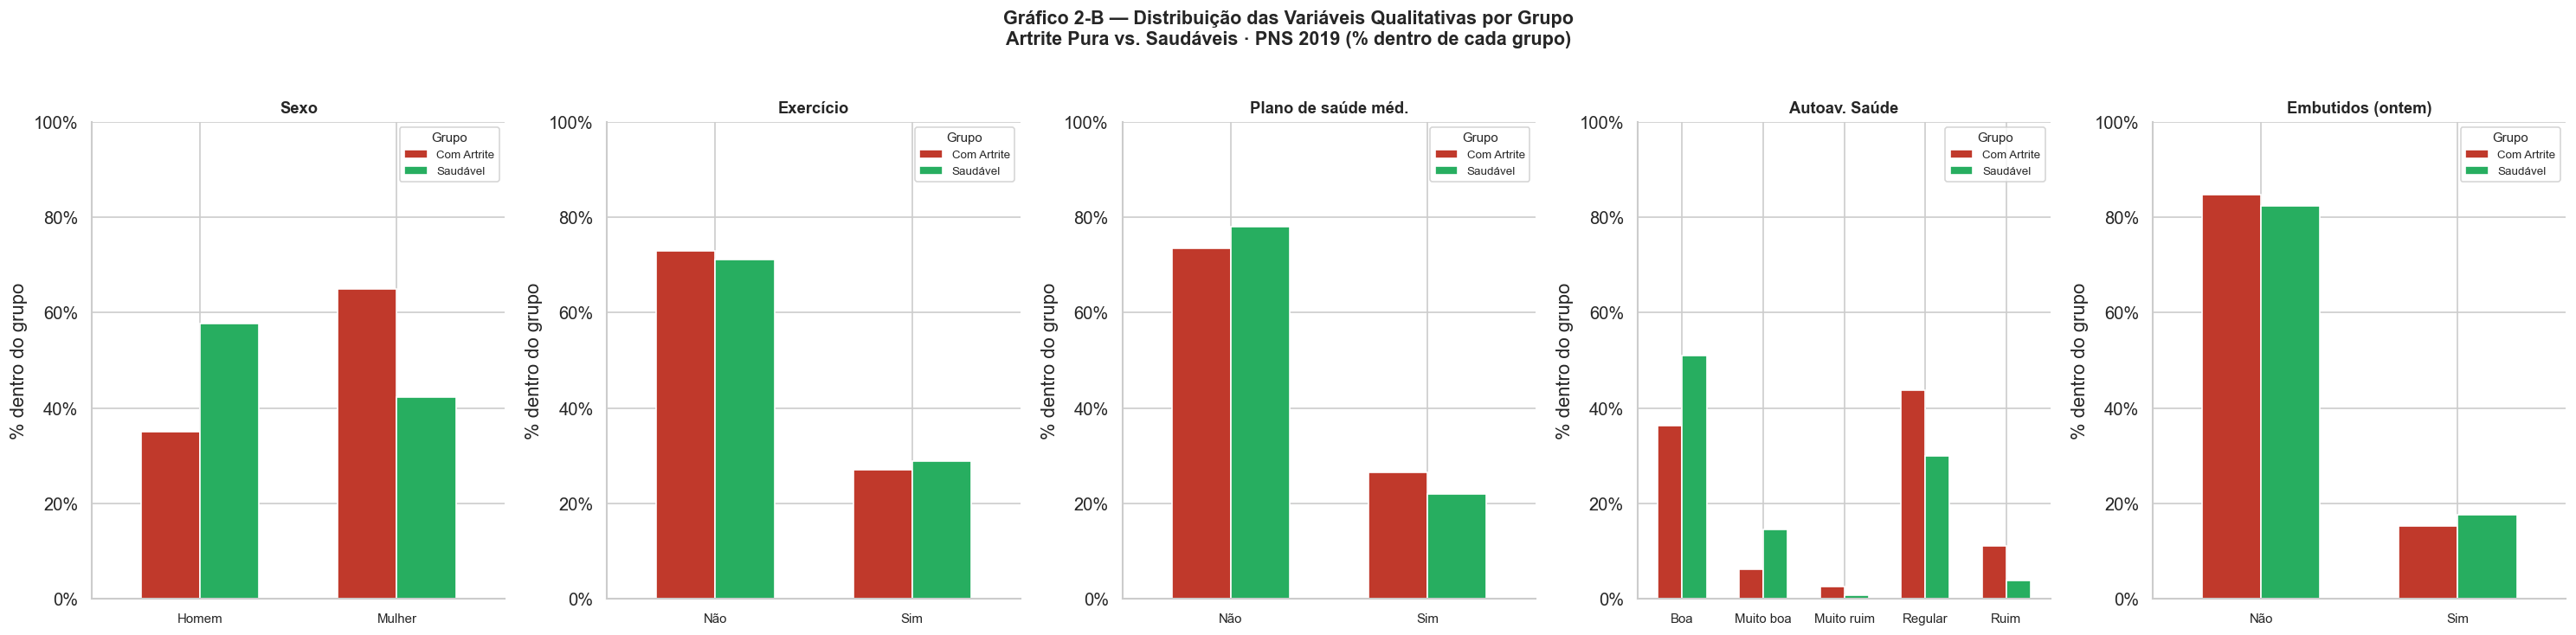

In [10]:
# ── Gráfico 2-B: barras agrupadas com eixo Y correto em % ────────────────
# BUG 4 CORRIGIDO: multiplicado por 100 + PercentFormatter + ylim(0,100)
# BUG 5 CORRIGIDO: sum(axis=1) em vez do sum(1) depreciado
# CORREÇÃO BUG 14: Q092 removida de VARS_BAR (variável constante)
# CORREÇÃO BUG 19: normalização agora por GRUPO (axis=1/sum(axis=0)), não por categoria
VARS_BAR = {'C006':'Sexo', 'P034':'Exercício', 'I00102':'Plano de saúde méd.', 'N001':'Autoav. Saúde', 'P00620':'Embutidos (ontem)'}  # Variáveis para visualizar em barras
MAP_BAR  = {'C006':MAP_SEXO, 'P034':MAP_SN, 'I00102':MAP_SN, 'N001':MAP_N001, 'P00620':MAP_SN}  # Mapas de códigos para cada variável

fig, axes = plt.subplots(1, len(VARS_BAR), figsize=(5*len(VARS_BAR), 6))  # Cria subplots (1 linha, múltiplas colunas)

for ax, (col, label) in zip(axes, VARS_BAR.items()):  # Para cada variável
    df_tmp      = df_biv[['Classe', col]].copy()  # Cria cópia com apenas Classe e coluna
    df_tmp[col] = (df_tmp[col].astype(str).str.strip()  # Converte para string e remove espaços
                              .map(MAP_BAR.get(col, {})).fillna(df_tmp[col]))  # Aplica mapeamento (código→texto)
    tabela     = pd.crosstab(df_tmp[col], df_tmp['Classe'])  # Tabela de contingência: categorias vs grupos
    # CORREÇÃO BUG 19: normalizar por GRUPO (coluna), não por categoria (linha)
    # tabela.sum(axis=0) = total de cada grupo; axis=1 divide cada coluna pelo seu total
    tabela_pct = tabela.div(tabela.sum(axis=0), axis=1) * 100  # Normaliza cada coluna para 100% e multiplica por 100

    tabela_pct.plot(kind='bar', ax=ax,  # Cria gráfico de barras
                   color=[COR_ARTRITE, COR_SAUDAVEL],  # Cores para Artrite e Saudável
                   width=0.6, edgecolor='white', rot=0)  # Dimensões e rotação
    ax.set_title(label, fontsize=11, fontweight='bold')  # Título do subplot
    ax.set_xlabel('')  # Sem rótulo X
    ax.set_ylabel('% dentro do grupo')  # Rótulo Y
    ax.set_ylim(0, 100)  # Limita Y de 0 a 100%
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))  # Formata Y como percentagem
    ax.legend(title='Grupo', fontsize=8, title_fontsize=9)  # Legenda
    ax.tick_params(axis='x', labelsize=9)  # Tamanho de fonte do eixo X

fig.suptitle('Gráfico 2-B — Distribuição das Variáveis Qualitativas por Grupo\n'  # Título
             'Artrite Pura vs. Saudáveis · PNS 2019 (% dentro de cada grupo)',  # Subtítulo
             fontsize=13, fontweight='bold', y=1.02)  # Formatação
plt.tight_layout()  # Ajusta espaçamento automaticamente
salvar_fig('grafico_2B_barras_qualitativas.png')  # Salva figura
plt.show()  # Mostra figura


---
## 2.3 · Bivariada — Artrite Pura vs. Saudáveis
**Produto:** Tabela 2-C

> **Bug 7 corrigido:** bivariada agora inclui todas as variáveis alimentares e de sedentarismo.

In [11]:
g_art = df_biv[df_biv['Classe']=='Com Artrite']  # Filtra apenas grupo Artrite
g_sau = df_biv[df_biv['Classe']=='Saudável']  # Filtra apenas grupo Saudável
linhas2c = []  # Lista para armazenar linhas da tabela 2-C

# ── Variáveis Quantitativas: Mann-Whitney ou Teste t ─────────────────────
for col, rotulo in VARS_QUANT.items():  # Para cada variável quantitativa
    s1 = g_art[col].dropna()  # Dados Artrite (sem NaN)
    s2 = g_sau[col].dropna()  # Dados Saudável (sem NaN)
    if len(s1) < 5 or len(s2) < 5: continue  # Pula se menos de 5 observações em algum grupo

    _, pn1 = stats.shapiro(s1.sample(min(len(s1),5000), random_state=RANDOM_STATE))  # Teste Shapiro Artrite
    _, pn2 = stats.shapiro(s2.sample(min(len(s2),5000), random_state=RANDOM_STATE))  # Teste Shapiro Saudável
    normal = (pn1 > ALPHA) and (pn2 > ALPHA)  # Ambos normais?

    if normal:  # Se ambos normais
        sv, p_val = stats.ttest_ind(s1, s2)  # Usa teste t (paramétrico)
        teste = 'Teste t'  # Identifica teste
        stat_s = f't={sv:.3f}'  # Estatística do teste
    else:  # Se algum não-normal
        sv, p_val = stats.mannwhitneyu(s1, s2, alternative='two-sided')  # Usa Mann-Whitney U (não-paramétrico)
        teste = 'Mann-Whitney U'  # Identifica teste
        stat_s = f'U={sv:.0f}'  # Estatística do teste

    # CORREÇÃO BUG 20: docstring obrigatória para o artigo
    # IC 95% da diferença de medianas via bootstrap percentílico (2000 amostras).
    # Método: reamostrar com reposição cada grupo independentemente, calcular a
    # diferença de medianas em cada réplica e extrair os percentis 2,5 e 97,5.
    # Referência: Efron B, Tibshirani RJ. An Introduction to the Bootstrap.
    #             Chapman & Hall/CRC, 1993. (Método do percentil — Seção 13.3)
    np.random.seed(RANDOM_STATE)  # Define seed para reproducibilidade
    diffs = [s1.sample(len(s1), replace=True).median() -  # Mediana de amostra bootstrap Artrite
             s2.sample(len(s2), replace=True).median() for _ in range(2000)]  # Menos mediana bootstrap Saudável (2000 vezes)
    ic_i, ic_s = np.percentile(diffs, [2.5, 97.5])  # Extrai percentis 2.5 e 97.5 da distribuição de diferenças

    linhas2c.append({  # Adiciona linha da tabela
        'Variável'         : rotulo,  # Nome da variável
        'Tipo'             : 'Quantitativa',  # Tipo de variável
        'Artrite Med(IQR)' : f'{s1.median():.1f} ({s1.quantile(.25):.1f}–{s1.quantile(.75):.1f})',  # Mediana (IQR) Artrite
        'Saudável Med(IQR)': f'{s2.median():.1f} ({s2.quantile(.25):.1f}–{s2.quantile(.75):.1f})',  # Mediana (IQR) Saudável
        'Teste'            : teste,  # Nome do teste
        'Estatística'      : stat_s,  # Valor da estatística
        'p-valor'          : f'{p_val:.4e}',  # p-valor em notação científica
        'IC95% dif.med.'   : f'[{ic_i:.2f}; {ic_s:.2f}]',  # IC 95% da diferença de medianas
        'Sig. α=5%'        : sig(p_val),  # Classificação de significância
    })

# ── Variáveis Qualitativas: Qui-Quadrado ou Fisher ────────────────────────
for col, (rotulo, mapa) in VARS_QUAL.items():  # Para cada variável qualitativa
    serie = df_biv[col].astype(str).str.strip()  # Converte para string, remove espaços
    if mapa: serie = serie.map(mapa).fillna(serie)  # Aplica mapeamento código→texto
    tab_ct = pd.crosstab(serie, df_biv['Classe'])  # Tabela de contingência
    if tab_ct.empty or tab_ct.shape[0] < 2: continue  # Pula se vazio ou só 1 categoria

    if tab_ct.values.min() < 5 and tab_ct.shape == (2,2):  # Se tabela 2x2 com células <5
        odds, p_val = stats.fisher_exact(tab_ct.values)  # Teste exato de Fisher
        teste = 'Fisher Exato'  # Identifica teste
        stat_s = f'OR={odds:.3f}'  # Odds Ratio como estatística
    else:  # Se tabela tem células ≥5 ou é maior que 2x2
        chi2, p_val, dof, _ = stats.chi2_contingency(tab_ct)  # Teste χ²
        teste = 'Qui-Quadrado'  # Identifica teste
        stat_s = f'χ²={chi2:.3f}'  # Estatística χ²

    m1 = serie[df_biv['Classe']=='Com Artrite'].dropna().mode()  # Moda em Artrite (vazio se 100% NaN)
    m2 = serie[df_biv['Classe']=='Saudável'].dropna().mode()  # Moda em Saudável (vazio se 100% NaN)
    if m1.empty or m2.empty: continue  # Sem moda calculável → pula variável
    mod1, mod2 = m1.iloc[0], m2.iloc[0]
    linhas2c.append({  # Adiciona linha
        'Variável'         : rotulo,  # Nome da variável
        'Tipo'             : 'Qualitativa',  # Tipo de variável
        'Artrite Med(IQR)' : f'Moda: {mod1}',  # Moda em Artrite
        'Saudável Med(IQR)': f'Moda: {mod2}',  # Moda em Saudável
        'Teste'            : teste,  # Nome do teste
        'Estatística'      : stat_s,  # Valor da estatística
        'p-valor'          : f'{p_val:.4e}',  # p-valor
        'IC95% dif.med.'   : '—',  # Não aplicável para qualitativas
        'Sig. α=5%'        : sig(p_val),  # Significância
    })

tab2c = pd.DataFrame(linhas2c)  # Cria dataframe da tabela
print('='*110)  # Linha decorativa
print('  TABELA 2-C — Bivariada Completa: Artrite Pura vs. Saudáveis')  # Título
print('  *** p<0,001  ** p<0,01  * p<0,05  ns = não significativo')  # Legenda de significância
print('='*110)  # Linha decorativa
print(tab2c.to_string(index=False))  # Mostra tabela
salvar_tab(tab2c, 'tabela_2C_bivariada_completa.csv')  # Salva tabela

# MELHORIA 25: Alerta interpretativo para achados contraintuitivos
# Identificar automaticamente variáveis com direção oposta à hipótese inflamatória
print()  # Linha em branco
print('='*110)  # Linha decorativa
print('  ⚠️  ATENÇÃO — ACHADOS CONTRAINTUITIVOS (MELHORIA 25): Viés de Causalidade Reversa')  # Título de alerta
print('='*110)  # Linha decorativa
# MELHORIA 25 (revisada): a DIREÇÃO é CALCULADA dos dados (antes era hardcoded).
# Definimos a direção ESPERADA de Artrite vs Saudável pela hipótese inflamatória; a direção
# OBSERVADA vem das medianas reais; só marcamos CONTRAINTUITIVO quando observado contradiz o
# esperado E o resultado é significativo (na Tab 2-C).
COD_POR_ROTULO = {rotulo: cod for cod, rotulo in VARS_QUANT.items()}  # inverte VARS_QUANT
DIRECAO_ESPERADA = {  # rótulo -> direção esperada de Artrite em relação a Saudável
    'Frutas (dias/sem.)'                       : 'menor',   # protetor: espera-se Artrite < Saudável
    'Verduras (dias/sem.)'                     : 'menor',   # protetor
    'Suco de fruta natural (dias/sem.)'        : 'menor',   # protetor
    'Refrigerante (dias/sem.)'                 : 'maior',   # pró-inflamatório: espera-se Artrite > Saudável
    'Doces/ultraproc. (dias/sem.)'             : 'maior',   # pró-inflamatório
    'Substituir almoço por lanche (dias/sem.)' : 'maior',   # ultraprocessado
}
alertas_encontrados = []  # variáveis com achado CONTRAINTUITIVO (significativo + direção oposta)
for rotulo, dir_esp in DIRECAO_ESPERADA.items():
    cod = COD_POR_ROTULO.get(rotulo)
    if cod is None or cod not in df_biv.columns: continue
    s_art = pd.to_numeric(df_biv[df_biv['Classe']=='Com Artrite'][cod], errors='coerce').dropna()
    s_sau = pd.to_numeric(df_biv[df_biv['Classe']=='Saudável'][cod], errors='coerce').dropna()
    if len(s_art) < 5 or len(s_sau) < 5: continue
    med_art, med_sau = s_art.median(), s_sau.median()
    linha = tab2c[tab2c['Variável'] == rotulo]            # significância calculada na Tab 2-C
    sig_str = linha['Sig. α=5%'].iloc[0] if not linha.empty else 'ns'
    if sig_str == 'ns' or med_art == med_sau: continue
    dir_obs = 'maior' if med_art > med_sau else 'menor'
    op, op_esp = ('>' if dir_obs=='maior' else '<'), ('>' if dir_esp=='maior' else '<')
    contraintuitivo = (dir_obs != dir_esp)
    marca = '⚠️ CONTRAINTUITIVO' if contraintuitivo else 'coerente c/ hipótese'
    print(f"  • {rotulo:42s} | {sig_str:4s} | Artrite {op} Saudável (med {med_art:.1f} vs {med_sau:.1f})"
          f" | esperado: Artrite {op_esp} Saudável | {marca}")
    if contraintuitivo:
        alertas_encontrados.append(rotulo)

if alertas_encontrados:  # Se há achados contraintuitivos
    print()  # Linha em branco
    print('  INTERPRETAÇÃO (para a seção Discussão do artigo):')  # Cabeçalho
    print('  Os achados acima são consistentes com viés de causalidade reversa (reverse causation),')  # Explicação
    print('  documentado na literatura como comportamento pós-diagnóstico: pacientes que recebem')  # Cont.
    print('  diagnóstico de artrite tendem a modificar hábitos alimentares buscando melhora clínica,')  # Cont.
    print('  aumentando consumo de frutas e reduzindo refrigerantes em relação ao período pré-diagnóstico.')  # Cont.
    print('  Este padrão é uma limitação inerente ao delineamento transversal da PNS 2019')  # Cont.
    print('  (exposição e desfecho medidos simultaneamente), e DEVE ser explicitamente discutido')  # Cont.
    print('  na seção Discussão do artigo científico.')  # Cont.
    print()  # Linha em branco
    print('  REFERÊNCIA SUGERIDA: Hernán MA, Hernández-Díaz S, Robins JM. A structural approach')  # Referência
    print('  to selection bias. Epidemiology. 2004;15(5):615-625.')  # Cont.
    print('  + Citar limitação do design transversal da PNS (IBGE, 2019).')  # Cont.
else:  # Se não há achados contraintuitivos
    print('  Nenhum achado contraintuitivo significativo detectado.')  # Mensagem neutra
print('='*110)  # Linha decorativa


  TABELA 2-C — Bivariada Completa: Artrite Pura vs. Saudáveis
  *** p<0,001  ** p<0,01  * p<0,05  ns = não significativo
                                Variável         Tipo                            Artrite Med(IQR)                           Saudável Med(IQR)          Teste Estatística    p-valor IC95% dif.med. Sig. α=5%
                            Idade (anos) Quantitativa                            67.0 (63.0–75.0)                            67.0 (63.0–73.0) Mann-Whitney U   U=1125555 5.7926e-02  [-1.00; 2.00]        ns
                             IMC (kg/m²) Quantitativa                            25.3 (22.8–28.4)                            24.8 (22.5–27.5) Mann-Whitney U   U=1149886 6.1311e-03   [0.04; 0.88]        **
                           Renda (faixa) Quantitativa                               4.0 (3.0–5.0)                               4.0 (3.0–5.0) Mann-Whitney U   U=1068880 9.7534e-01  [-1.00; 0.00]        ns
                   Exercício (dias/sem.) Quantitativa      

---
## 2.4 · Correlação entre Preditoras
**Produtos:** Gráfico 2-D · Tabela 2-D

> **Bug 3 corrigido:** heatmap agora tem dados reais porque as colunas alimentares  
> são carregadas desde a Célula 1.

  Registros com todas as variáveis preenchidas: 0 (de 4,826 totais — correlação usa pares válidos por par)


  ✅ Figura → ../data/results/eda/figuras/grafico_2D_heatmap_correlacoes.png


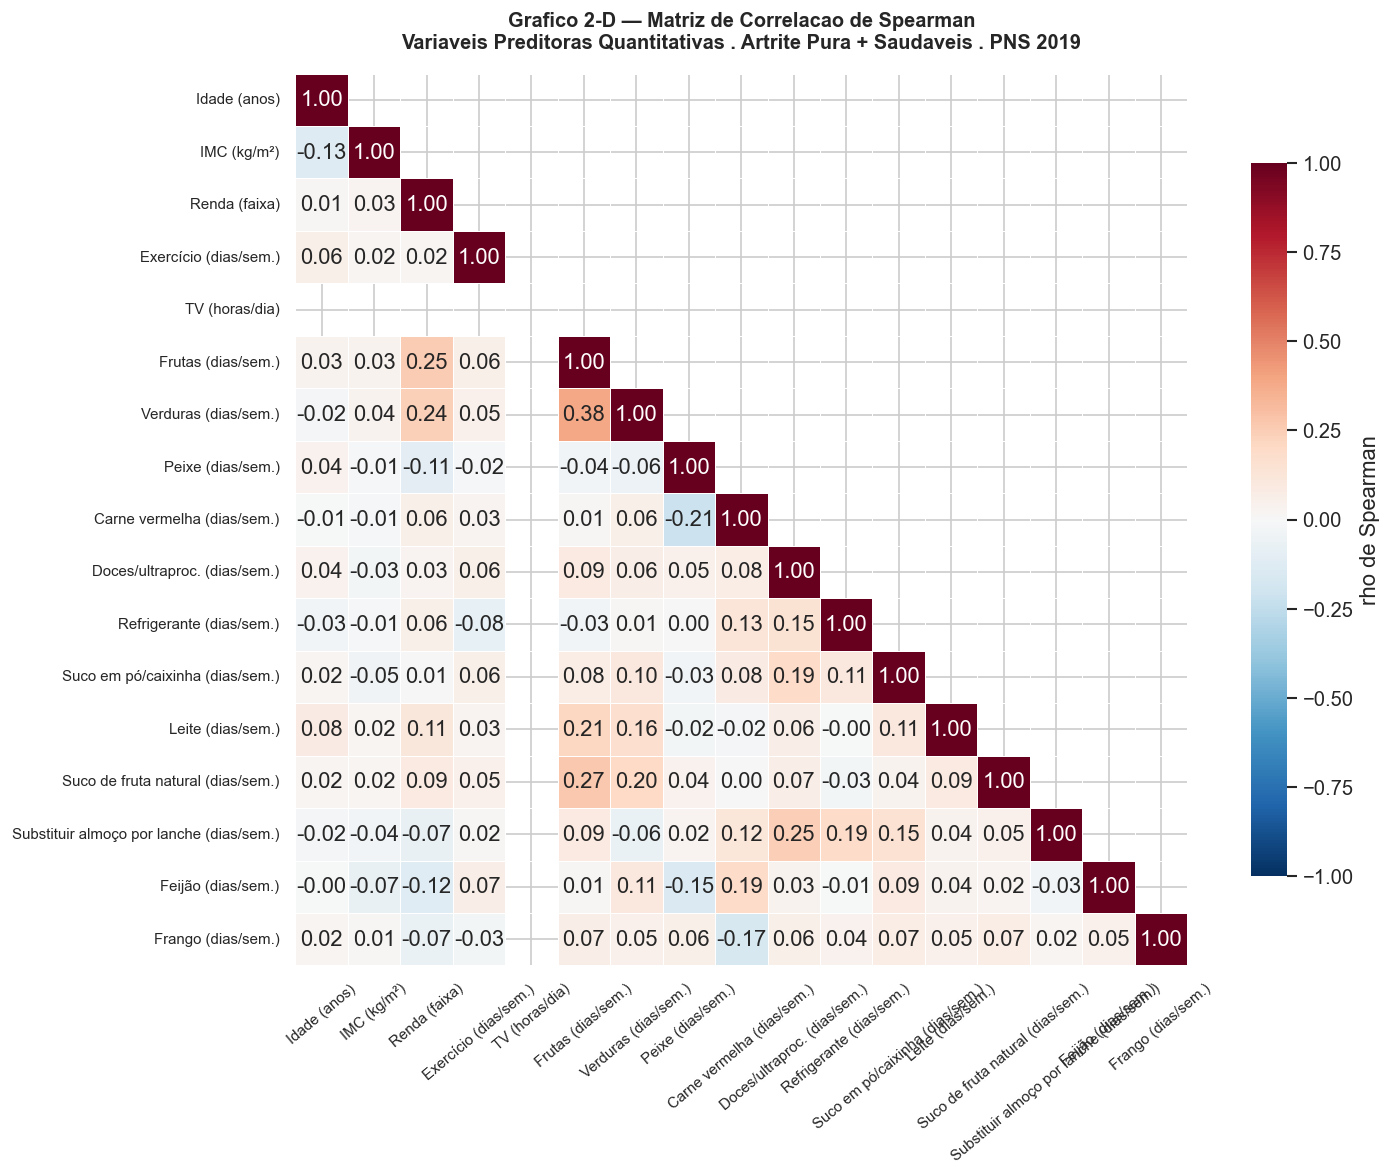


  TABELA 2-D — Pares com |rho| > 0,50  (acima de 0,70 = multicolinearidade)
  Nenhum par com |rho| > 0,50.
  ✅ Tabela → ../data/results/eda/tabelas/tabela_2D_correlacoes_relevantes.csv


In [12]:
# ── Célula 2.4 · Correlação entre Preditoras ────────────────────────────
#
# BUG A CORRIGIDO: dropna() sobre TODAS as colunas simultâneas → 0 linhas.
#   df_biv tem variáveis alimentares (P015, P035…) com muitos NaN independentes.
#   Exigir que UMA linha tenha as 10 colunas preenchidas ao mesmo tempo elimina
#   praticamente todos os registros.
#   CORREÇÃO: usar correlação pairwise (pandas.corr já é pairwise por padrão).
#   Cada par de variáveis usa apenas as linhas válidas PARA AQUELE PAR.
#
# BUG B CORRIGIDO: KeyError: 'ρ Spearman'
#   Quando 'pares' é uma lista vazia, pd.DataFrame([]) cria um DataFrame SEM
#   colunas. sort_values('ρ Spearman') lança KeyError porque a coluna não existe.
#   CORREÇÃO: guardar a chave ASCII 'rho_Spearman' para sort_values e só
#   renomear para o rótulo final após a ordenação. Guard 'if not tab2d.empty'.

cols_corr = list(VARS_QUANT.keys())  # Lista de códigos de variáveis para correlacionar
labs_corr = list(VARS_QUANT.values())  # Lista de rótulos para essas variáveis

# Converte para numérico SEM dropna global — pandas.corr é pairwise por padrão
df_corr = df_biv[cols_corr].apply(pd.to_numeric, errors='coerce')  # Converte todas colunas para número; NaN se inválido

n_completos = int(df_corr.dropna().shape[0])  # Contar linhas com TODAS as colunas preenchidas
print(f'  Registros com todas as variáveis preenchidas: {n_completos:,} '  # Mostra contagem
      f'(de {len(df_biv):,} totais — correlação usa pares válidos por par)')  # Com explicação

# Correlação de Spearman pairwise (min_periods=30 rejeita pares com poucos dados)
corr_mat = df_corr.corr(method='spearman', min_periods=30)  # Calcula correlação Spearman pairwise (mínimo 30 pares)
corr_mat.columns = labs_corr  # Renomeia colunas com rótulos legíveis
corr_mat.index   = labs_corr  # Renomeia linhas com rótulos legíveis

# ── Heatmap (triângulo inferior) ──────────────────────────────────────────
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)  # Cria máscara para triângulo superior (descarta duplicatas)
fig, ax = plt.subplots(figsize=(13, 10))  # Cria figura de heatmap
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',  # Heatmap: valores anotados com 2 casas decimais
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,  # Cor: vermelho-azul centrado em 0, escala -1 a +1
            linewidths=0.5, linecolor='white', ax=ax, square=True,  # Espaçamento e forma
            cbar_kws={'label': 'rho de Spearman', 'shrink': 0.8})  # Legenda da barra de cor
ax.set_title('Grafico 2-D — Matriz de Correlacao de Spearman\n'  # Título
             'Variaveis Preditoras Quantitativas . Artrite Pura + Saudaveis . PNS 2019',  # Subtítulo
             fontsize=12, fontweight='bold', pad=15)  # Formatação
ax.tick_params(axis='x', labelrotation=40, labelsize=9)  # Rotaciona labels X
ax.tick_params(axis='y', labelrotation=0,  labelsize=9)  # Labels Y horizontais
plt.tight_layout()  # Ajusta espaçamento
salvar_fig('grafico_2D_heatmap_correlacoes.png')  # Salva figura
plt.show()  # Mostra figura

# ── Tabela 2-D: pares com |rho| > 0,50 ───────────────────────────────────
# Calcula spearmanr por par usando apenas linhas validas para aquele par
pares = []  # Lista para armazenar pares com correlação relevante
for i in range(len(cols_corr)):  # Para cada variável (primeira do par)
    for j in range(i+1, len(cols_corr)):  # Para cada variável posterior (segunda do par)
        par = df_corr[[cols_corr[i], cols_corr[j]]].dropna()  # Extrai par, remove NaN
        if len(par) < 30:            # par com dados insuficientes: pula
            continue  # Próximo par
        r, p_r = stats.spearmanr(par.iloc[:, 0], par.iloc[:, 1])  # Correlação Spearman do par
        if abs(r) > 0.50:  # Se correlação em valor absoluto > 0.50
            interp = ('Alta' if abs(r) > 0.70  # Interpretação: Alta se |r| > 0.70
                      else 'Moderada-Alta' if abs(r) > 0.60 else 'Moderada')  # Intermediária ou Moderada
            pares.append({  # Adiciona à lista
                'Variavel 1'   : labs_corr[i],  # Primeira variável
                'Variavel 2'   : labs_corr[j],  # Segunda variável
                'rho_Spearman' : round(r, 3),   # chave ASCII para sort_values
                'p-valor'      : f'{p_r:.4e}',  # p-valor
                'Sig.'         : sig(p_r),  # Significância
                'n par'        : len(par),  # Tamanho da amostra para este par
                'Interpretacao': interp,  # Força da correlação
            })

tab2d = pd.DataFrame(pares)  # Cria dataframe da tabela

# BUG B CORRIGIDO: so ordena e renomeia se o DataFrame nao estiver vazio
if not tab2d.empty:  # Se há pares com |rho| > 0.50
    tab2d = tab2d.sort_values('rho_Spearman', key=abs, ascending=False)  # Ordena por valor absoluto, decrescente
    tab2d = tab2d.rename(columns={'rho_Spearman': 'rho Spearman'})  # Renomeia coluna com caractere grego

print('\n' + '='*75)  # Linha decorativa
print('  TABELA 2-D — Pares com |rho| > 0,50  (acima de 0,70 = multicolinearidade)')  # Título
print('='*75)  # Linha decorativa
print(tab2d.to_string(index=False) if not tab2d.empty  # Se há pares
      else '  Nenhum par com |rho| > 0,50.')  # Se não há pares
salvar_tab(tab2d, 'tabela_2D_correlacoes_relevantes.csv')  # Salva tabela


---
## ✅ Sumário Final — Produtos Gerados

In [13]:
produtos = [  # Lista de tuplas (nome_produto, caminho_arquivo, descrição)
    ('Tabela 3-B', DIR_TABELAS+'tabela_3B_prevalencia_subgrupos.csv',    'Prevalência por subgrupo com IC 95%'),  # Prevalência
    ('Tabela 3-A', DIR_TABELAS+'tabela_3A_descritiva_quatro_bases.csv',  'Descritiva das 4 bases (coortes sobrepostas)'),  # Comparação bases (descritiva)
    ('Tabela 3-A (testes)', DIR_TABELAS+'tabela_3A_contrastes_validos.csv',  'Contrastes válidos vs Saudáveis (Mann-Whitney)'),  # Contrastes disjuntos
    ('Tabela 2-A', DIR_TABELAS+'tabela_2A_univariada_quantitativas.csv', 'Características basais: quantitativas'),  # Univariada quantitativa
    ('Tabela 2-B', DIR_TABELAS+'tabela_2B_univariada_qualitativas.csv',  'Características basais: qualitativas'),  # Univariada qualitativa
    ('Tabela 2-C', DIR_TABELAS+'tabela_2C_bivariada_completa.csv',       'Bivariada completa com p-valores e IC 95%'),  # Bivariada
    ('Tabela 2-D', DIR_TABELAS+'tabela_2D_correlacoes_relevantes.csv',   'Pares de correlação com |ρ| > 0,50'),  # Correlações
    ('Gráfico 3-B', DIR_FIGURAS+'grafico_3B_prevalencia_subgrupos.png',  'Barras horizontais prevalência c/ IC 95%'),  # Gráfico prevalência
    ('Gráfico 3-A', DIR_FIGURAS+'grafico_3A_boxplots_quatro_bases.png',  'Box plots comparativos das 4 bases'),  # Gráfico comparação bases
    ('Gráfico 2-A', DIR_FIGURAS+'grafico_2A_boxplots_quantitativas.png', 'Box plots quantitativas por grupo'),  # Gráfico univariada quant
    ('Gráfico 2-B', DIR_FIGURAS+'grafico_2B_barras_qualitativas.png',    'Barras agrupadas qualitativas'),  # Gráfico univariada qual
    ('Gráfico 2-D', DIR_FIGURAS+'grafico_2D_heatmap_correlacoes.png',    'Heatmap matriz de correlação de Spearman'),  # Gráfico correlação
]

print('='*85)  # Linha decorativa
print('  ✅  PRODUTOS GERADOS — Fases 2 e 3 · PNS 2019')  # Título
print('  Filtro de integridade aplicado: V0015=1 (domicílio) + M001=1 (questionário)')  # Nota sobre filtros
print('='*85)  # Linha decorativa
for cod, path, desc in produtos:  # Para cada produto
    status = '✅' if os.path.exists(path) else '⚠️  NÃO GERADO'  # Verifica se arquivo existe
    print(f'  {status}  {cod:12s}  {desc}')  # Mostra status e descrição
print('='*85)  # Linha decorativa
print('  Melhorias aplicadas nesta versão:')  # Seção de melhorias
print('  [21] Tab 2-A e 2-B em formato wide (padrão JHI)')  # Melhoria 21
print('  [22] χ² + OR em vez de KW para variáveis binárias na Tab 3-A')  # Melhoria 22
print('  [23] Q092 removida do SQL_COMPLETO (limpeza de código)')  # Melhoria 23
print('  [24] Vars CAPTO: P02001=Suco em pó, P023=Leite, P01601=Suco natural, P02602=Subst. almoço — em VARS_QUANT, Tab2A, Graf2A, Tab2C, Heatmap')  # Melhoria 24
print('  [26] Revisão dicionário: I00101->I00102 (plano médico); +P006 Feijão, +P013 Frango (dias/sem.); +P00620 Embutidos (qualit.)')  # Revisão
print('  [25] Alerta interpretativo automático para achados contraintuitivos (Tab 2-C)')  # Melhoria 25
print('='*85)  # Linha decorativa
print('  Próximo: Notebook 03 — Regressão Logística e Modelagem ML (Fase 4)')  # Próximos passos


  ✅  PRODUTOS GERADOS — Fases 2 e 3 · PNS 2019
  Filtro de integridade aplicado: V0015=1 (domicílio) + M001=1 (questionário)
  ✅  Tabela 3-B    Prevalência por subgrupo com IC 95%
  ✅  Tabela 3-A    Descritiva das 4 bases (coortes sobrepostas)
  ✅  Tabela 3-A (testes)  Contrastes válidos vs Saudáveis (Mann-Whitney)
  ✅  Tabela 2-A    Características basais: quantitativas
  ✅  Tabela 2-B    Características basais: qualitativas
  ✅  Tabela 2-C    Bivariada completa com p-valores e IC 95%
  ✅  Tabela 2-D    Pares de correlação com |ρ| > 0,50
  ✅  Gráfico 3-B   Barras horizontais prevalência c/ IC 95%
  ✅  Gráfico 3-A   Box plots comparativos das 4 bases
  ✅  Gráfico 2-A   Box plots quantitativas por grupo
  ✅  Gráfico 2-B   Barras agrupadas qualitativas
  ✅  Gráfico 2-D   Heatmap matriz de correlação de Spearman
  Melhorias aplicadas nesta versão:
  [21] Tab 2-A e 2-B em formato wide (padrão JHI)
  [22] χ² + OR em vez de KW para variáveis binárias na Tab 3-A
  [23] Q092 removida do SQL_CO